# 1. Importation of Python libraries for modeling analysis.

In [1]:
# Data handling
import os
import re
import math
import numpy as np
import pandas as pd
import pickle
import matplotlib.dates as mdates
from tqdm import tqdm
from itertools import product

# Visualization
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
from tabulate import tabulate

# Statistical modelling & diagnostics
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# SciPy stats (distribution tests & transforms)
from scipy import stats
from scipy.stats import skewtest, kurtosistest, skew, kurtosis, boxcox, jarque_bera, shapiro, normaltest
from scipy.special import inv_boxcox

# Warnings
import warnings
warnings.filterwarnings("ignore")

---

# 2. General Functions

    - Function to format results into a table

In [2]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".4f"))

    - Function to find optimal ARIMA model parameters

In [3]:
def optimal_arima_parameters(serie: pd.Series, max_p: int = 6, max_d: int = 2, max_q: int = 6, horizon: int = 15, orders: list |None = None, hide_progress: bool = False):
    """
    Grid-search (p, d, q) for ARIMA on a possibly transformed series (Box–Cox).
    Lambda is inferred from the series name in the form BoxCox_lambda{...}.
    For each specification, returns fit metrics and both fitted/forecast series on the transformed scale and inverted back to the original scale.
    The "enforce_stationarity" is set to True, ensuring that the AR parameters correspond to a stationary process.
    The "enforce_invertibility" is set to True, ensuring that the MA parameters correspond to an invertible process.

    Parameters
    ----------
    serie (pd.Series): Training series
    max_p, max_d, max_q (int): Inclusive search bounds for p, d, q.
    horizon (list[int]): Forecast horizon to evaluate.
    orders (list): Predefined list of (p, d, q, trend) combinations to evaluate instead of the full grid search.
    hide_progress (bool): result presentation control

    Returns
    -------
    models (list): [serie, model, residuals, p, d, q, trend, horizon, AIC, BIC, HQIC, fitted_transform, forecast_transform, fitted_original, forecast_original]
    """

    lambda_bc = None
    # Search for the value of lambda in the series name
    if serie.name:
        m = re.search(r"\{([^}]*)\}", str(serie.name))
        if m:
            try:
                lambda_bc = float(m.group(1))
                if hide_progress == False:
                    print(f"\nThe serie being evaluated is: {serie.name}")
            except ValueError:
                lambda_bc = None
        elif str(serie.name) == "Original_serie":
            if hide_progress == False:
                print(f"\nThe serie being evaluated is: {serie.name}")   
        else:
            if hide_progress == False:
                print("\nThe Box-Cox transformation name of the serie should be something like: BoxCox_lambda{0}")

    models = []
    combinations = []

    if orders:
        for ord in orders:
            p, d, q, trend = ord
            combinations.append((int(p), int(d), int(q), trend))
            total_combinations = len(combinations)
    else:
        grid = list(product(range(max_p+1), range(max_d+1), range(max_q+1)))
        for (p, d, q) in grid:
            trends = (["n", "c", "t", "ct"] if d == 0
                      else ["n", "t"] if d == 1
                      else ["n"])

            for trend in trends:
                combinations.append((p, d, q, trend))
                total_combinations = len(combinations)

    for (p, d, q, trend) in tqdm(combinations, total=total_combinations, ncols=100, colour="green", desc="Grid Search", disable=hide_progress):
        try:
            model = ARIMA(serie, order=(p, d, q), trend=trend, enforce_stationarity=True, enforce_invertibility=True).fit()

            # Fitted/forecast on transform scale
            fitted_transform = model.fittedvalues
            forecast_transform = model.get_forecast(steps=horizon).predicted_mean

            # Reversion to the original serie scale
            if lambda_bc is None:
                fitted_original = fitted_transform.copy()
                forecast_original = forecast_transform.copy()
            else:
                fitted_original = inv_boxcox(fitted_transform.values, lambda_bc)
                forecast_original = inv_boxcox(forecast_transform.values, lambda_bc)

            models.append({"serie_train": serie.name,
                           "model": model,
                           "residuals": model.resid.dropna(),
                           "p": p, "d": d, "q": q, "trend": trend, "horizon": horizon,
                           "AIC": model.aic, "BIC": model.bic, "HQIC": model.hqic,
                           "fitted_transform": fitted_transform,
                           "forecast_transform": forecast_transform,
                           "fitted_original": fitted_original,
                           "forecast_original": forecast_original})

        except Exception as e:
            print(f"(p{p},d{d},q{q},trend={trend}) -> {type(e).__name__}: {e}")
            continue

    return models

    - Function to compute Freedman–Diaconis bins

In [4]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as: width = 2 * IQR / n^(1/3), where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

    - Function of Diebold–Mariano test

In [5]:
def diebold_mariano(y_true: pd.DataFrame, y_pred1: np.array, y_pred2: np.array, h, alpha: float = 0.05, name1: str = "Model_1", name2: str = "Model_2", loss: str = "ae", small_sample=True):
    """
    Diebold–Mariano test for equal predictive accuracy between two forecast series.

    Parameters
    ----------
    y_true (pd.DataFrame): True observed values.
    y_pred1 (array): Forecasts from model 1.
    y_pred2 (array): Forecasts from model 2.
    h (int): Forecast horizon (steps ahead).
    alpha (float): Significance level used for the reject_H0 flag.
    name1 (str): Label of model 1.
    name2 (str): Label of model 2.
    small_sample : bool, default=True
        If True and h > 1, apply Harvey–Leybourne–Newbold (HLN) small-sample
        adjustment to the DM statistic and use a t distribution with df = n - 1.
        Otherwise use the standard normal approximation.

    Returns
    -------
    pandas.DataFrame
        - model_1 (str): name of the first model
        - model_2 (str): name of the second model
        - h (int): forecast horizon
        - stat (float): DM test statistic (HLN adjusted if applicable)
        - pvalue (float): two-sided p-value
        - reject_H0 (bool): True if pvalue < alpha
        - best (str): name of the model with lower average loss (or "Draw")
    """

    y_true  = np.asarray(y_true["Close"].iloc[:len(y_pred1)], float)
    y_pred1 = np.asarray(y_pred1, float)
    y_pred2 = np.asarray(y_pred2, float)

    # --- Loss series ---
    if loss == "rse":
        l1 = np.sqrt((y_true - y_pred1) ** 2)
        l2 = np.sqrt((y_true - y_pred2) ** 2)
    elif loss == "ae":
        l1 = np.abs(y_true - y_pred1)
        l2 = np.abs(y_true - y_pred2)
    elif loss == "ape":
        l1 = np.abs((y_true - y_pred1) / np.abs(y_true)) * 100.0
        l2 = np.abs((y_true - y_pred2) / np.abs(y_true)) * 100.0
    else:
        raise ValueError("loss must be one of {'rse','ae','ape'}")
    
    # loss differential
    d = l1 - l2
    # Mean loss differential
    dbar = d.mean()
    # Centered series for HAC variance estimation
    x = d - dbar

    # HAC (Bartlett) variance with L = h - 1
    L = max(int(h) - 1, 0)
    # gamma_0
    gamma0 = np.dot(x, x) / len(y_true)
    hac = gamma0
    for k in range(1, L + 1):
        cov = np.dot(x[k:], x[:-k]) / len(y_true)
        w = 1.0 - k / (L + 1.0)         # Bartlett weight
        hac += 2.0 * w * cov

    var_dbar = hac / len(y_pred1)
    
    # DM statistic
    stat = dbar / np.sqrt(var_dbar)

    # HLN small-sample adjustment
    if small_sample:
        adj = np.sqrt((len(y_true) + 1 - 2*h + (h*(h - 1))/len(y_true)) / len(y_true))
        dm_adj = stat * adj
        df = len(y_true) - 1
        pval = 2 * (1 - stats.t.cdf(np.abs(dm_adj), df=df))
        stat_out = dm_adj
    else:
        pval = 2 * (1 - stats.norm.cdf(np.abs(stat)))
        stat_out = stat

    best = name1 if dbar < 0 else (name2 if dbar > 0 else "Draw")

    dm_results = pd.DataFrame([{"model_1": name1,
                                "model_2": name2,
                                "h": int(h),
                                "stat": float(stat_out),
                                "pvalue": float(pval),
                                "reject_H0": bool(pval < alpha),  # True if different predictive accuracy
                                "best": best,
                                "mean_loss_1": float(l1.mean()),
                                "mean_loss_2": float(l2.mean()),
                                "mean_diff": float(dbar)}])
    return dm_results

    - Function of Clark–West test

In [6]:
def clark_west(y: pd.DataFrame, yhat_small: np.array, yhat_large: np.array, h: int = 1, alpha: float = 0.05):
    """
    Clark–West test for models (one-sided).
    Tests whether the larger (more parameterized) model has strictly lower MSFE
    than the smaller model, correcting for the estimation noise bias.

    Parameters
    ----------
    y (pd.DataFrame): True observed values.
    yhat_small (array): Forecasts of worst model.
    yhat_large (array): Forecasts of better model.
    h (int): Forecast horizon (steps ahead).

    Returns
    -------
    pandas.DataFrame:
        - h (int): forecast horizon
        - stat (float): Clark–West t-statistic (one-sided test)
        - pvalue: one-sided p-value
        - Decision:
            H0: pvalue <= 0 (no improvement from the large model)
            H1: pvalue  > 0 (large model improves MSFE)
    """
     
    y  = np.asarray(y["Close"].iloc[:len(yhat_small)], float)
    yhat_small = np.asarray(yhat_small, float)
    yhat_large = np.asarray(yhat_large, float)

    # CW adjusted differential
    e_s, e_l = y - yhat_small, y - yhat_large
    d = (e_s**2) - (e_l**2 - (yhat_large - yhat_small)**2)

    # Mean loss differential
    dbar = np.mean(d)
    # centered series for HAC variance estimation
    x = d - dbar

    # --- Newey–West HAC variance (lag = h-1) ---
    L = max(int(h) - 1, 0)
    hac = np.dot(x, x) / len(y)
    for k in range(1, L + 1):
        cov = (x[k:] * x[:-k]).sum() / len(y)
        w = 1.0 - k / (L + 1.0)  # Bartlett weight
        hac += 2.0 * w * cov

    var_dbar = hac / len(y)

    t_stat = dbar / np.sqrt(var_dbar)

    # one-sided p-value
    p = 1 - stats.norm.cdf(t_stat)

    return pd.DataFrame([{"h": int(h),
                          "stat": float(t_stat),
                          "pvalue": float(p),
                          "reject_H0": bool(p < alpha),
                          "RMSFE_small": float(np.sqrt((e_s**2).mean())),
                          "RMSFE_large": float(np.sqrt((e_l**2).mean())),
                          "mean_diff": float(np.sqrt(dbar))}])

---

# 3. Upload of Time Series Data

In [7]:
# Full file path to the CSV file previously saved
file_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"

# Load CSV into DataFrame with Date as index
df_Ativo = pd.read_csv(file_path, header=0, index_col=0, parse_dates=True)

# Extract only the "Close" column
df_Ativo_close = df_Ativo["Close"]

# Create a new Dataframe containing only the "Close" prices
df = pd.DataFrame(df_Ativo_close.copy())

---

# 4. Data Preparation for ARIMA Modeling

    ---------------------------------------------------------------------------------------------------------------------------

    4.1. Time series and candidate transformations for ARIMA model evaluation

In [8]:
# Original Time Series and Candidate transformations
df_boxcox_0     = pd.Series(boxcox(df["Close"].values, lmbda=0), index=df["Close"].index, name="BoxCox_lambda{0}")
df_boxcox_01830 = pd.Series(boxcox(df["Close"].values, lmbda=0.1830), index=df["Close"].index, name="BoxCox_lambda{0.1830}")
df_series       = pd.DataFrame({"Original_serie"       : df["Close"],
                                "BoxCox_lambda{0}"     : df_boxcox_0,
                                "BoxCox_lambda{0.1830}": df_boxcox_01830})

display_table(df_series.tail(), "Time series and candidate transformations (last 5 rows):")


Time series and candidate transformations (last 5 rows):
╒═════════════════════╤══════════════════╤════════════════════╤═════════════════════════╕
│        Date         │  Original_serie  │  BoxCox_lambda{0}  │   BoxCox_lambda{0.1830} │
╞═════════════════════╪══════════════════╪════════════════════╪═════════════════════════╡
│ 2025-08-10 00:00:00 │   119306.7578    │      11.6895       │                 40.9420 │
├─────────────────────┼──────────────────┼────────────────────┼─────────────────────────┤
│ 2025-08-11 00:00:00 │   118731.4453    │      11.6846       │                 40.9010 │
├─────────────────────┼──────────────────┼────────────────────┼─────────────────────────┤
│ 2025-08-12 00:00:00 │   120172.9062    │      11.6967       │                 41.0035 │
├─────────────────────┼──────────────────┼────────────────────┼─────────────────────────┤
│ 2025-08-13 00:00:00 │   123344.0625    │      11.7227       │                 41.2255 │
├─────────────────────┼──────────────────┼

    ---------------------------------------------------------------------------------------------------------------------------

    4.2. Plot of the Time series and candidate transformations

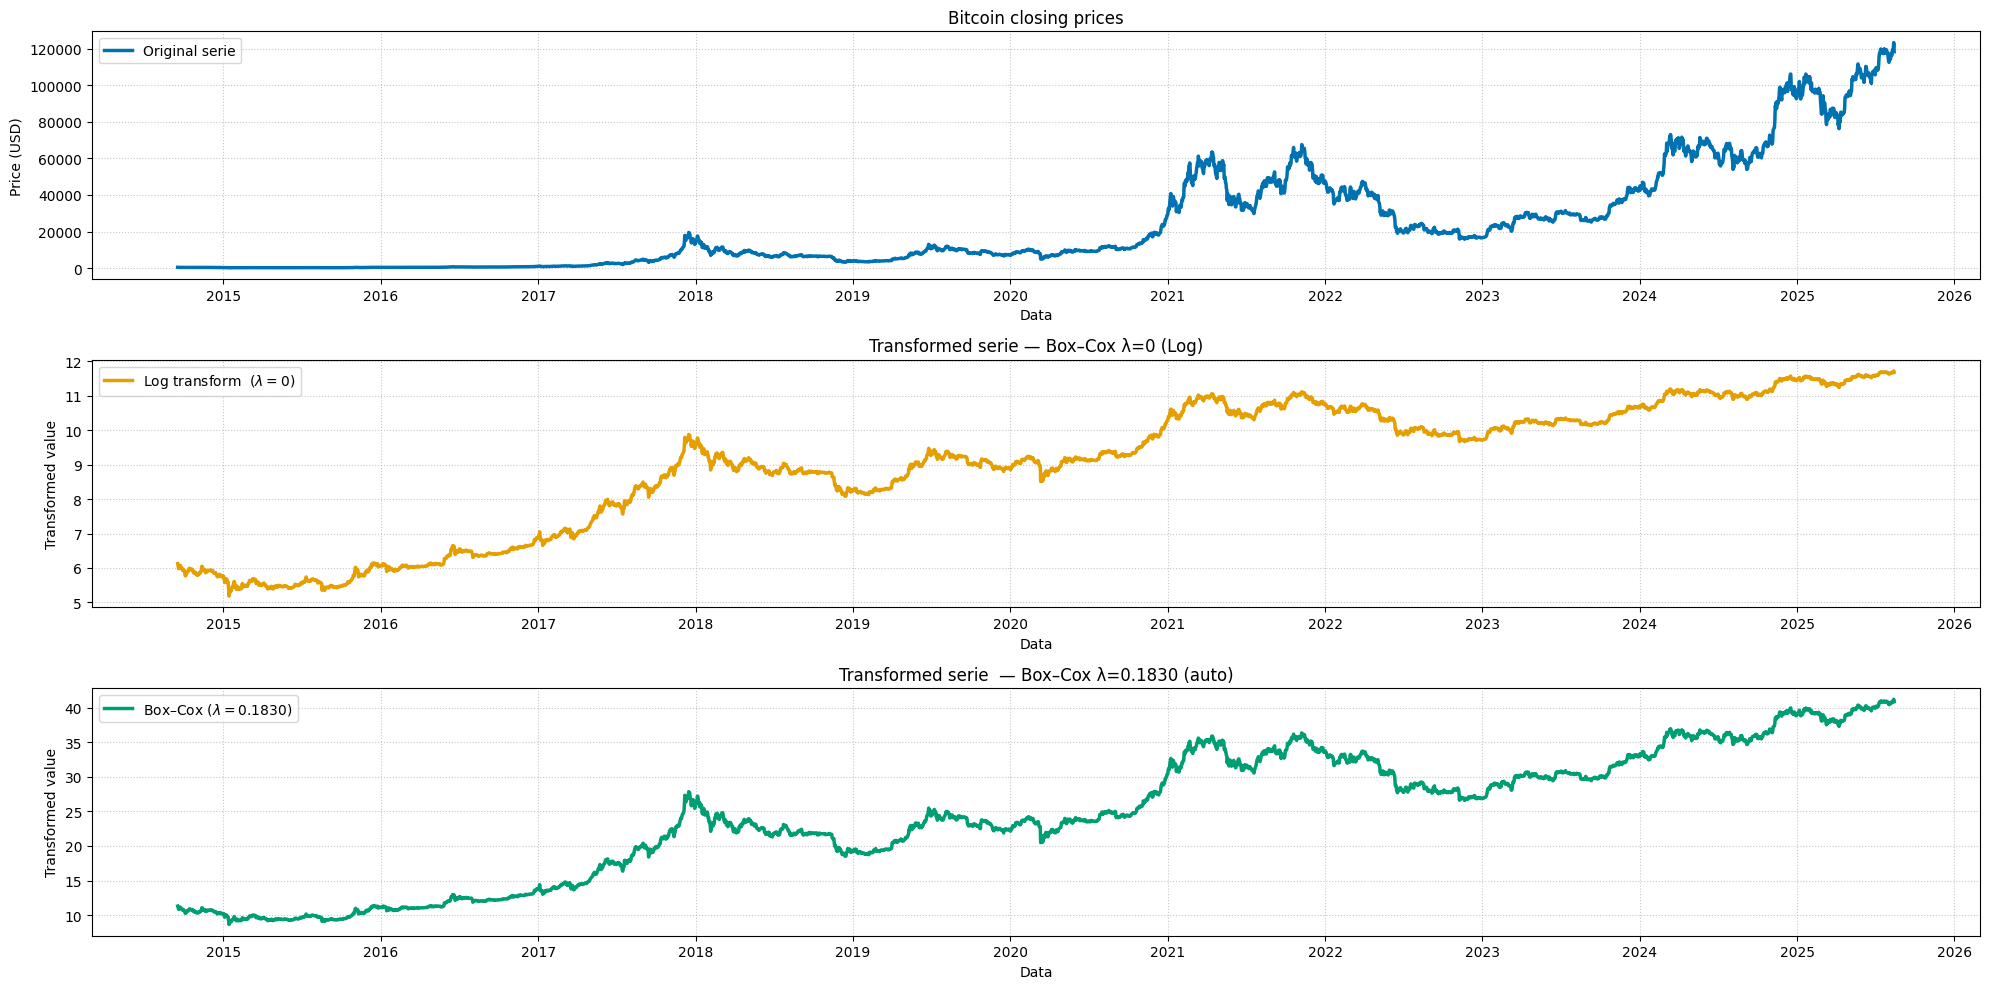

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Original serie
axes[0].plot(df["Close"].index, df["Close"].values, color="#0072B2", label='Original serie', lw=2.5)
axes[0].set_title("Bitcoin closing prices")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc='best')
axes[0].grid(True, linestyle=":", alpha=0.7)

# Box–Cox with λ=0 (Log)
axes[1].plot(df["Close"].index, df_boxcox_0.values, color="#E69F00", label='Log transform  ($\\lambda=0$)', lw=2.5)
axes[1].set_title("Transformed serie — Box–Cox λ=0 (Log)")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Transformed value")
axes[1].legend(loc='best')
axes[1].grid(True, linestyle=":", alpha=0.7)

# Box–Cox with optimal λ=0.1830
axes[2].plot(df["Close"].index, df_boxcox_01830.values, color="#009E73", label='Box–Cox ($\\lambda=0.1830$)', lw=2.5)
axes[2].set_title("Transformed serie  — Box–Cox λ=0.1830 (auto)")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Transformed value")
axes[2].legend(loc='best')
axes[2].grid(True, linestyle=":", alpha=0.7)

# Anual ticks for the 3 plots
year_locator = mdates.YearLocator()
year_fmt     = mdates.DateFormatter("%Y")
for ax in axes:
    ax.xaxis.set_major_locator(year_locator)
    ax.xaxis.set_major_formatter(year_fmt)

plt.tight_layout()
plt.show()

    ---------------------------------------------------------------------------------------------------------------------------

    4.3. Train-Test Split and Data visualization

--- Dataset ---
Observations: 3985
Training Observations: 3188 (2014-09-17 00:00:00 → 2023-06-09 00:00:00)
Testing  Observations: 797  (2023-06-10 00:00:00 → 2025-08-14 00:00:00)


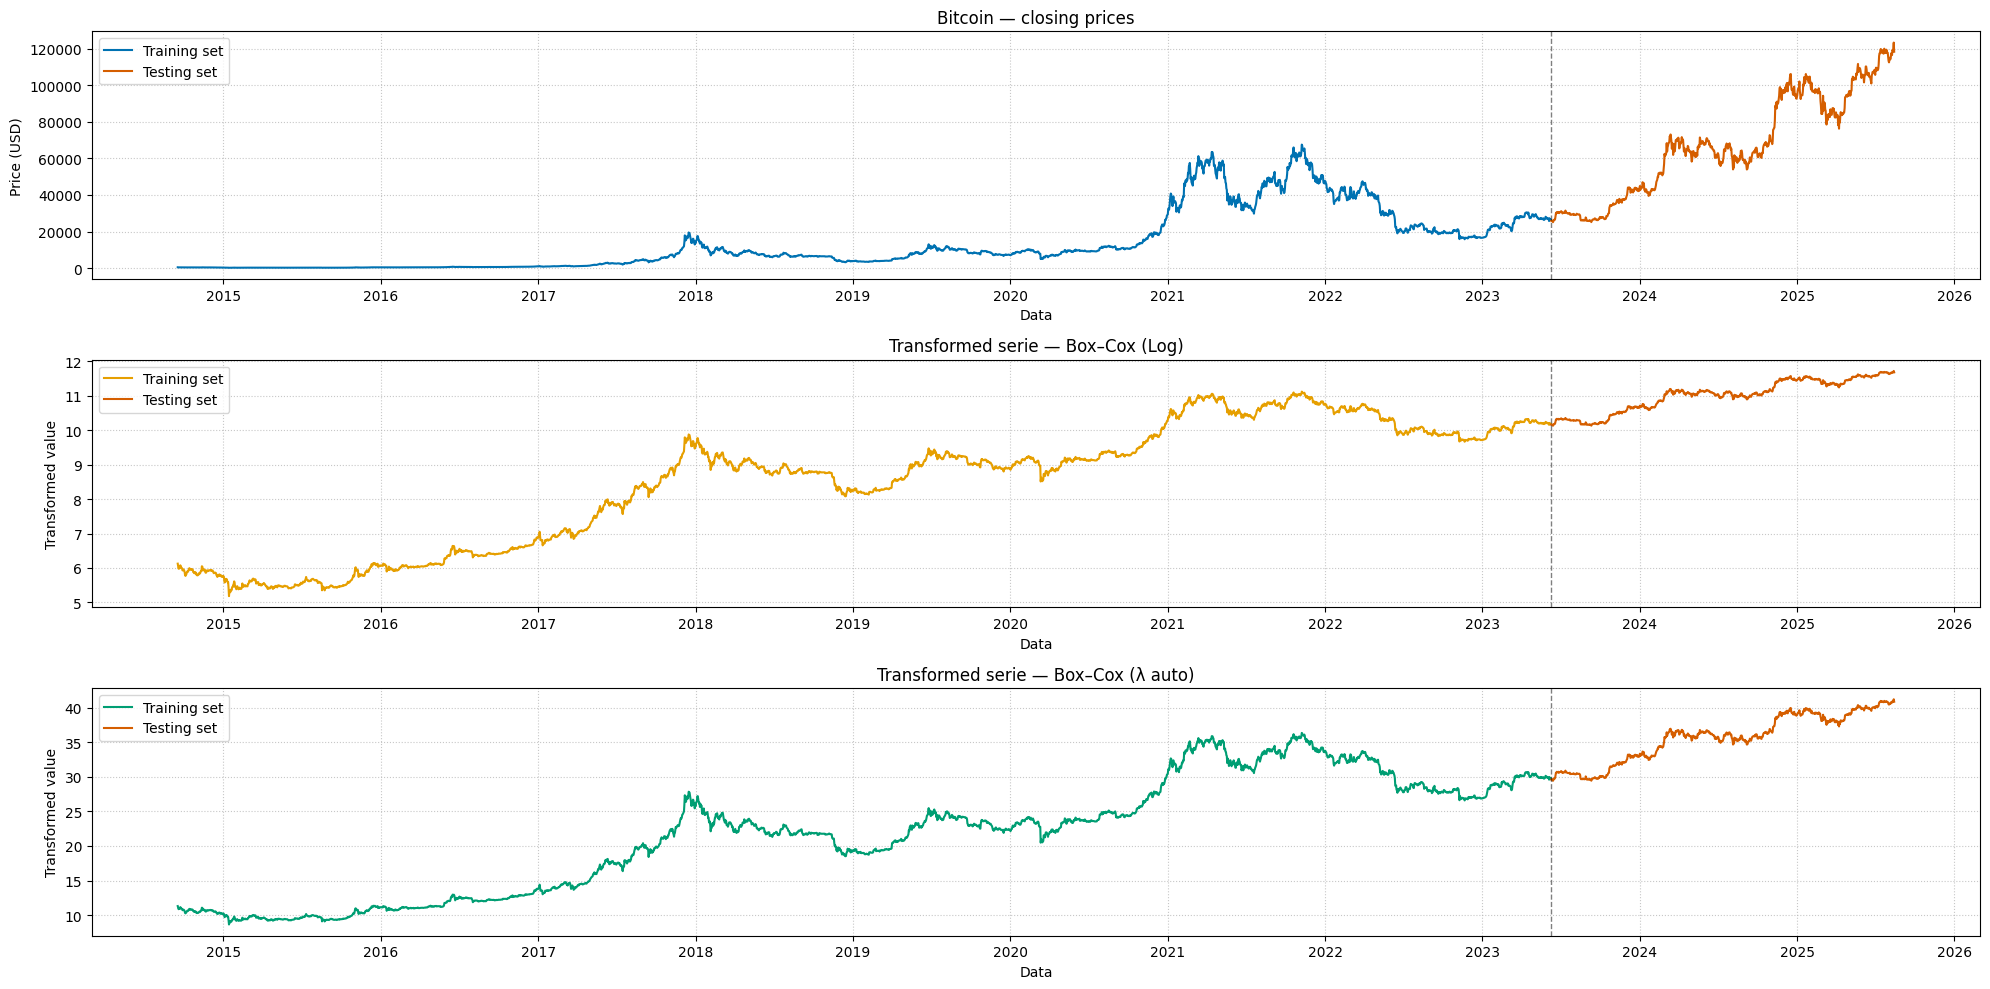

In [10]:
# 80/20 split
train_size = int(len(df) * 0.80)
split_ts   = df.index[train_size - 1]

# Original serie split
df_train_original = df.iloc[:train_size].copy()
df_test_original  = df.iloc[train_size:].copy()

# Box–Cox with λ=0 (Log) serie split
df_train_boxcox_0 = df_boxcox_0.iloc[:train_size].copy()
df_test_boxcox_0  = df_boxcox_0.iloc[train_size:].copy()

# Box–Cox with optimal λ=0.1830 serie split
df_train_boxcox_01830 = df_boxcox_01830.iloc[:train_size].copy()
df_test_boxcox_01830  = df_boxcox_01830.iloc[train_size:].copy()

# Series dataframe split
df_series_train = df_series.iloc[:train_size].copy()
df_series_test  = df_series.iloc[train_size:].copy()

print("--- Dataset ---")
print(f"Observations: {len(df)}")
print(f"Training Observations: {len(df_train_original)} ({df_train_original.index.min()} → {df_train_original.index.max()})")
print(f"Testing  Observations: {len(df_test_original)}  ({df_test_original.index.min()} → {df_test_original.index.max()})")

fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Original serie
axes[0].plot(df_train_original.index, df_train_original.values, color="#0072B2", label="Training set")
axes[0].plot(df_test_original.index,  df_test_original.values,  color="#D55E00", label="Testing set")
axes[0].axvline(split_ts, linestyle="--", linewidth=1, color="k", alpha=0.5)
axes[0].set_title("Bitcoin — closing prices")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="best")
axes[0].grid(True, linestyle=":", alpha=0.7)

# Box–Cox with λ=0 (Log)
axes[1].plot(df_train_boxcox_0.index, df_train_boxcox_0.values, color="#E69F00", label="Training set")
axes[1].plot(df_test_boxcox_0.index,  df_test_boxcox_0.values,  color="#D55E00", label="Testing set")
axes[1].axvline(split_ts, linestyle="--", linewidth=1, color="k", alpha=0.5)
axes[1].set_title("Transformed serie — Box–Cox (Log)")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Transformed value")
axes[1].legend(loc="best")
axes[1].grid(True, linestyle=":", alpha=0.7)

# Box–Cox with optimal λ=0.1830
axes[2].plot(df_train_boxcox_01830.index, df_train_boxcox_01830.values, color="#009E73", label="Training set")
axes[2].plot(df_test_boxcox_01830.index,  df_test_boxcox_01830.values,  color="#D55E00", label="Testing set")
axes[2].axvline(split_ts, linestyle="--", linewidth=1, color="k", alpha=0.5)
axes[2].set_title("Transformed serie — Box–Cox (λ auto)")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Transformed value")
axes[2].legend(loc="best")
axes[2].grid(True, linestyle=":", alpha=0.7)

# Anual ticks for the 3 plots
year_locator = mdates.YearLocator()
year_fmt     = mdates.DateFormatter("%Y")
for ax in axes:
    ax.xaxis.set_major_locator(year_locator)
    ax.xaxis.set_major_formatter(year_fmt)

plt.tight_layout()
plt.show()

As shown by Gholamy, Kreinovich, and Kosheleva (2018), an 80/20 split was used, 80% of the data for the training set and 20% for the test set.

    ---------------------------------------------------------------------------------------------------------------------------

---

# 5. Creation and Storage of ARIMA Models

In [11]:
# # Create the directory for ARIMA models objects
# ARIMA_MODELS_DIR = "arima_models_objects"
# os.makedirs(ARIMA_MODELS_DIR, exist_ok=True)

# # Fit ARIMA models for each candidate series
# # Duration: 55 min
# for col in df_series_train.columns:
#     serie_train = df_series_train[col]
#     serie_train.name = col
#     results = optimal_arima_parameters(serie_train, max_p=6, max_d=2, max_q=6, hide_progress=False)
        
#     results_models = [{"serie":              res.get("serie", col),
#                        "p":                  res["p"],
#                        "d":                  res["d"], 
#                        "q":                  res["q"], 
#                        "trend":              res["trend"], 
#                        "horizon":            res["horizon"],
#                        "AIC":                res["AIC"], 
#                        "BIC":                res["BIC"], 
#                        "HQIC":               res["HQIC"],
#                        "residuals":          res["residuals"],
#                        "fitted_original":    res["fitted_original"],
#                        "fitted_transform":   res["fitted_transform"],
#                        "forecast_original":  res["forecast_original"],
#                        "forecast_transform": res["forecast_transform"],}
#                        for res in results]

#     # Always overwrite the file on each run
#     pkl_path = os.path.join(ARIMA_MODELS_DIR, f"{col}_mdl_obj.pkl")
#     with open(pkl_path, "wb") as f:
#         pickle.dump(results_models, f, protocol=pickle.HIGHEST_PROTOCOL)

- 343 models were developed for the Original Time Series and the candidate transformations.

# 6. Fitting and Model Identification

    6.1. Loading of ARIMA model results

In [12]:
# Load results of the time series and candidate transformations
ARIMA_MODELS_DIR = "arima_models_objects"
with open(os.path.join(ARIMA_MODELS_DIR, "Original_serie_mdl_obj.pkl"), "rb") as f:
    mdl_obj_original    = pickle.load(f)
    df_mdl_obj_original = pd.DataFrame(mdl_obj_original)
with open(os.path.join(ARIMA_MODELS_DIR, "BoxCox_lambda{0}_mdl_obj.pkl"), "rb") as f:
    mdl_obj_bc0    = pickle.load(f)
    df_mdl_obj_bc0 = pd.DataFrame(mdl_obj_bc0)
with open(os.path.join(ARIMA_MODELS_DIR, "BoxCox_lambda{0.1830}_mdl_obj.pkl"), "rb") as f:
    mdl_obj_bc01830    = pickle.load(f)
    df_mdl_obj_bc01830 = pd.DataFrame(mdl_obj_bc01830)

# DataFrame with the metrics of the time series and candidate transformations
df_mdl_obj_metrics_raw = pd.concat([df_mdl_obj_original, df_mdl_obj_bc0, df_mdl_obj_bc01830],ignore_index=True)

display_table(df_mdl_obj_original.head(1), "ARIMA Models — Original Series")
display_table(df_mdl_obj_bc0.head(1),      "ARIMA Models — Box-Cox Transformation (λ = 0)")
display_table(df_mdl_obj_bc01830.head(1),  "ARIMA Models — Box-Cox Transformation (λ = 0.1830)")
df_mdl_obj_metrics_raw.shape


ARIMA Models — Original Series
╒════╤════════════════╤═════╤═════╤═════╤═════════╤═══════════╤════════════╤════════════╤════════════╤══════════════════════════════╤══════════════════════════════╤══════════════════════════════╤═══════════════════════════════════════════════╤═══════════════════════════════════════════════╕
│    │     serie      │  p  │  d  │  q  │  trend  │  horizon  │    AIC     │    BIC     │    HQIC    │          residuals           │       fitted_original        │       fitted_transform       │               forecast_original               │ forecast_transform                            │
╞════╪════════════════╪═════╪═════╪═════╪═════════╪═══════════╪════════════╪════════════╪════════════╪══════════════════════════════╪══════════════════════════════╪══════════════════════════════╪═══════════════════════════════════════════════╪═══════════════════════════════════════════════╡
│ 0  │ Original_serie │  0  │  0  │  0  │    n    │    15     │ 72484.0873 │ 72490.1544 │ 72

(1029, 14)

- The data consist of 3188 days of observations and 1029 total models built for the Original Time Series and the candidate transformations.

    ---------------------------------------------------------------------------------------------------------------------------

    6.2. Residual analysis of ARIMA models

    6.2.1 Presentation of the residuals of the ARIMA models for the original time series and its candidate transformations

In [13]:
def df_residuals(df_models: pd.DataFrame, squared: bool = False):
    """
    Build a residuals DataFrame with one row per ARIMA model, replacing time indices by sequential horizon labels (h=2, ..., h=15).

    Parameters
    ----------
    df_models (pd.DataFrame): DataFrame containing ARIMA model outputs.
    squared (bool, [default=False]): IF True, give the squared residuals

    Returns
    -------
    df_res (pd.DataFrame): DataFrame of residuals where, each row corresponds to one ARIMA model, columns are labeled h=2, h=3, ..., up to the length of residuals.
    """
    rows = []

    # Build dictionary of a model name for a residual vector
    for _, r in df_models.iterrows():
        # Extract basic model info
        serie = r["serie"]
        model = f"ARIMA({int(r['p'])},{int(r['d'])},{int(r['q'])})"
        trend = r["trend"]

        # Clean residuals and ensure numeric 1D array
        resid = pd.Series(r["residuals"]).iloc[1:]
        resid = pd.to_numeric(resid, errors="coerce").to_numpy(dtype=float)

        if squared:
            resid = resid ** 2
        
        # Store as dictionary
        row = {"serie": serie, "model": model, "trend": trend}
        row.update({f"h={h}": val for h, val in enumerate(resid, start=2)})
        rows.append(row)

    df_res = pd.DataFrame(rows)

    return df_res

df_residuals_original_series = df_residuals(df_mdl_obj_original)
df_residuals_bc0             = df_residuals(df_mdl_obj_bc0)
df_residuals_bc01830         = df_residuals(df_mdl_obj_bc01830)

display_table(df_residuals_original_series.iloc[:5, :15], "Residuals — Original Serie")
display_table(df_residuals_bc0.iloc[:5, :15],             "Residuals — Box-Cox λ=0 ")
display_table(df_residuals_bc01830.iloc[:5, :15],         "Residuals — Box-Cox λ=0.1830")


Residuals — Original Serie
╒════╤════════════════╤══════════════╤═════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╕
│    │     serie      │    model     │  trend  │     h=2     │     h=3     │     h=4     │     h=5     │     h=6     │     h=7     │     h=8     │     h=9     │    h=10     │    h=11     │    h=12     │        h=13 │
╞════╪════════════════╪══════════════╪═════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0  │ Original_serie │ ARIMA(0,0,0) │    n    │  424.4400   │  394.7960   │  408.9040   │  398.8210   │  402.1520   │  435.7910   │  423.2050   │  411.5740   │  404.4250   │  399.5200   │  377.1810   │    375.4670 │
├────┼────────────────┼──────────────┼─────────┼─────────────┼─────────────┼─────────────┼─────────────┼

    6.2.2 Evaluation of the independence of the residuals of the ARIMA models for the original time series and its candidate transformations

In [14]:
def df_residual_independence_analysis(df_models: pd.DataFrame, alpha: float = 0.05, squared: bool = False):
    """
    Evaluate residual independence using the Ljung–Box test up to lag h=15.

    For each ARIMA model, the Ljung–Box test is applied to the residual vector formed by the horizon columns (h=2, ..., h=15).
    Each horizon column is relabeled as:
        - "Independent"     if residuals show no autocorrelation at that lag (p >= alpha)
        - "Autocorrelated"  if autocorrelation is detected (p <  alpha)

    Parameters
    ----------
    df_residuals (pd.DataFrame): DataFrame containing residuals per model with columns
    alpha (float)(default=0.05): Significance level for the Ljung–Box test. p >= alpha implies independence.
    squared (bool, [default=False]): IF True, use squared residuals for the Ljung–Box test

    Returns
    -------
    df_res_analysis (pd.DataFrame): DataFrame with the same shape as "df_residuals" for the horizon columns, where each cell contains "Independent" or "Autocorrelated".
    """
    # Create column names for each horizon (h=2, ..., h=15)
    h_cols = [f"h={h}" for h in range(2, 16)]
    
    # Define output table columns
    cols = list(("serie", "model", "trend")) + h_cols
    rows_df_res_analysis = []

    for _, row in df_models.iterrows():
        # Build idex table for each model (series name, ARIMA order, trend)
        index_table = pd.DataFrame({"serie": np.atleast_1d(row["serie"]),
                                    "model": [f"ARIMA({p},{d},{q})" for p, d, q in zip(np.atleast_1d(row["p"]), np.atleast_1d(row["d"]), np.atleast_1d(row["q"]))],
                                    "trend": np.atleast_1d(row["trend"])})

        # Define valid lags (2, ..., n)
        valid_lags = list(range(2, 16))

        # Ljung–Box test
        if squared:
            lb_df = acorr_ljungbox(row["residuals"][1:].values** 2, lags=valid_lags, return_df=True)
        else:
            lb_df = acorr_ljungbox(row["residuals"][1:].values, lags=valid_lags, return_df=True)
        pvals = dict(zip(valid_lags, lb_df["lb_pvalue"].to_numpy()))

        # Build one output row per model
        for i in range(len(index_table)):
            line = {"serie": index_table.loc[i, "serie"],
                    "model": index_table.loc[i, "model"],
                    "trend": index_table.loc[i, "trend"]}
            
            # Fill horizon columns with "Independent" or "Autocorrelated"
            for c in h_cols:
                h = int(c.split("=")[1])
                line[c] = "Independent" if pvals[h] >= alpha else "Autocorrelated"

            rows_df_res_analysis.append(line)

    df_res_analysis = pd.DataFrame(rows_df_res_analysis, columns=cols)

    return df_res_analysis

df_res_os_analysis      = df_residual_independence_analysis(df_mdl_obj_original)
df_res_bc0_analysis     = df_residual_independence_analysis(df_mdl_obj_bc0)
df_res_bc01830_analysis = df_residual_independence_analysis(df_mdl_obj_bc01830)

def summarize_autocorrelation(df_analysis: pd.DataFrame, title: str, h_max: int = 15):
    """
    Display summary table and count models with autocorrelated residuals in any lag up to h_max.

    Parameters
    ----------
    df_res_analysis (pd.DataFrame): DataFrame with the same shape as "df_residuals" for the horizon columns, where each cell contains "Independent" or "Autocorrelated".
    title (str): Descriptive title to be displayed above the summary table
    h_max (int)(default=15): Maximum horizon (lag) to be considered in the autocorrelation check.

    Returns
    ----------
    count_autocorr (int): Number of models that show autocorrelation in at least one lag up to h_max.
    """
    # Select horizon columns up to h_max
    h_cols = [c for c in df_analysis.columns if c.startswith("h=") and int(c.split("=")[1]) <= h_max]
    
    # Count models with at least one autocorrelated lag
    count_autocorr = (df_analysis[h_cols] == "Autocorrelated").any(axis=1).sum()
    
    # Display results
    display_table(df_analysis.head(5), f"Residual Independence — {title}")
    
    return count_autocorr

count_autocorr_os      = summarize_autocorrelation(df_res_os_analysis,      "Original Series")
count_autocorr_bc0     = summarize_autocorrelation(df_res_bc0_analysis,     "Box–Cox λ=0")
count_autocorr_bc01830 = summarize_autocorrelation(df_res_bc01830_analysis, "Box–Cox λ=0.1830")

print(f"\nNumber of Autocorrelated Models for Original Time Series:           {count_autocorr_os} /  {df_res_os_analysis.shape[0]}")
print(f"Number of Autocorrelated Models for BoxCox transformation λ=0:       {count_autocorr_bc0} /  {df_res_os_analysis.shape[0]}")
print(f"Number of Autocorrelated Models for BoxCox transformation λ=0.1830:  {count_autocorr_bc01830} /  {df_res_os_analysis.shape[0]}")
print("---"*20)
print(f"Total number of Autocorrelated Models:                              {count_autocorr_os + count_autocorr_bc0 + count_autocorr_bc01830} / {3 * df_res_os_analysis.shape[0]}")


Residual Independence — Original Series
╒════╤════════════════╤══════════════╤═════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╤════════════════╕
│    │     serie      │    model     │  trend  │      h=2       │      h=3       │      h=4       │      h=5       │      h=6       │      h=7       │      h=8       │      h=9       │      h=10      │      h=11      │      h=12      │      h=13      │      h=14      │ h=15           │
╞════╪════════════════╪══════════════╪═════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ 0  │ Original_serie │ ARIMA(0,0,0) │    n    │ Autocorrelated │ Autocorrelated │ Autocorrelated 

    6.2.3 Filtering the models with independent residuals up to 15 horizons

In [15]:
def filter_independent_models(df_indep: pd.DataFrame):
    """
    Filter and return only models whose residuals are independent across all lags (h=1,...,h=n).

    Parameters
    ----------
    df_indep (pd.DataFrame): DataFrame containing the residual independence results of all ARIMA modelsS.

    Returns
    -------
    df_filter (pd.DataFrame): Filtered DataFrame containing only models whose residuals are classified as "Independent" for all tested horizons.
    """
    # Identify horizon columns those that start with "h="
    h_cols = [c for c in df_indep.columns if c.startswith("h=")]

    # Keep rows where residuals are "Independent" for all horizons
    mask = (df_indep[h_cols] == "Independent").all(axis=1)

    df_filter = df_indep[mask].reset_index(drop=True)

    return df_filter

df_indep_res_original_serie = filter_independent_models(df_res_os_analysis)
df_indep_res_bc0            = filter_independent_models(df_res_bc0_analysis)
df_indep_res_bc01830        = filter_independent_models(df_res_bc01830_analysis)

display_table(df_indep_res_original_serie.head(5),"Independent Residual Models — Original Serie")
display_table(df_indep_res_bc0.head(5),"Independent Residual Models — Box-Cox λ=0")
display_table(df_indep_res_bc01830.head(5),"Independent Residual Models — Box-Cox λ=0.1830")

print(f"\nNumber of Independent models for Original Time Series:           {df_indep_res_original_serie.shape[0]}")
print(f"Number of Independent models for BoxCox transformation λ=0:      {df_indep_res_bc0.shape[0]}")
print(f"Number of Independent models for BoxCox transformation λ=0.1830: {df_indep_res_bc01830.shape[0]}")
print("---"*20)
print(f"Total number of models:                              {df_indep_res_original_serie.shape[0] + df_indep_res_bc0.shape[0] + df_indep_res_bc01830.shape[0]}")


Independent Residual Models — Original Serie
╒════╤════════════════╤══════════════╤═════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╕
│    │     serie      │    model     │  trend  │     h=2     │     h=3     │     h=4     │     h=5     │     h=6     │     h=7     │     h=8     │     h=9     │    h=10     │    h=11     │    h=12     │    h=13     │    h=14     │ h=15        │
╞════╪════════════════╪══════════════╪═════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0  │ Original_serie │ ARIMA(5,0,6) │    n    │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ Independent │ In

- After creating a DataFrame containing the residuals of each model for the Original Time Series and its candidate transformations, residual independence was assessed up to a 15 day horizon. Following this analysis and subsequent filtering, 22 independent models were identified for the Original Time Series, 278 for the Box–Cox transformation with λ=0, and 271 for the Box–Cox transformation with λ=0,1830, out of a total of 343 models.

    ---------------------------------------------------------------------------------------------------------------------------

    6.3 Creation of a DataFrame with models presenting independent residuals up to 15 horizons

In [16]:
def select_independent_models(df_models: pd.DataFrame, df_indep: pd.DataFrame):
    """
    Filter and return only models whose residuals are independent across all lags (h=1,...,h=n).

    Parameters
    ----------
    df_models (pd.DataFrame): DataFrame containing the full set of evaluated ARIMA models, including model identifiers and metrics.
    df_indep (pd.DataFrame): DataFrame containing the residual independence results for ARIMA models.

    Returns
    -------
    df_models_filtered (pd.DataFrame): Filtered DataFrame containing only the models whose residuals are classified as "Independent".
    """
    # Parse p,d,q from models
    pdq         = df_indep['model'].str.extract(r'ARIMA\((\d+),(\d+),(\d+)\)').astype(int)
    pdq.columns = ['p','d','q']

    # Build key table
    key_table = pd.concat([df_indep[['serie','trend']].reset_index(drop=True), pdq], axis=1).drop_duplicates()

    # Filter via inner merge on the keys
    df_models_filtered = df_models.merge(key_table, on=['serie','trend','p','d','q'], how='inner')

    return df_models_filtered

df_mdl_res_indep_os      = select_independent_models(df_mdl_obj_original, df_indep_res_original_serie)
df_mdl_res_indep_bc0     = select_independent_models(df_mdl_obj_bc0, df_indep_res_bc0)
df_mdl_res_indep_bc01830 = select_independent_models(df_mdl_obj_bc01830, df_indep_res_bc01830)

display_table(df_mdl_res_indep_os.head(5),      "Models with independent residuals — Original Series")
display_table(df_mdl_res_indep_bc0.head(5),     "Models with independent residuals — BoxCox λ=0")
display_table(df_mdl_res_indep_bc01830.head(5), "Models with independent residuals — BoxCox λ=0.1830")

df_mdl_res_indep_all = pd.concat([df_mdl_res_indep_os, df_mdl_res_indep_bc0, df_mdl_res_indep_bc01830],ignore_index=True)
df_mdl_res_indep_all.shape


Models with independent residuals — Original Series
╒════╤════════════════╤═════╤═════╤═════╤═════════╤═══════════╤════════════╤════════════╤════════════╤══════════════════════════════╤══════════════════════════════╤══════════════════════════════╤═══════════════════════════════════════════════╤═══════════════════════════════════════════════╕
│    │     serie      │  p  │  d  │  q  │  trend  │  horizon  │    AIC     │    BIC     │    HQIC    │          residuals           │       fitted_original        │       fitted_transform       │               forecast_original               │ forecast_transform                            │
╞════╪════════════════╪═════╪═════╪═════╪═════════╪═══════════╪════════════╪════════════╪════════════╪══════════════════════════════╪══════════════════════════════╪══════════════════════════════╪═══════════════════════════════════════════════╪═══════════════════════════════════════════════╡
│ 0  │ Original_serie │  5  │  0  │  6  │    n    │    15     │ 51532.6

(571, 14)

- After the analysis and filtering, the dataset consists of 3,188 daily observations and a total of 571 models developed for the Original Time Series and its candidate transformations.

    ---------------------------------------------------------------------------------------------------------------------------

    6.4. Fitting Analysis of the Transformed Series

    6.4.1 Preliminary Selection of a Top 5 ARIMA Models by AIC, BIC and HQIC

In [17]:
def boxcox_log_jacobian(df_train_original: pd.DataFrame, label: str):
    """
    Compute the Box–Cox log-Jacobian term J = (λ − 1) * Σ log(y_i).

    Parameters
    ----------
    df_train_original (pd.Series): Original scale series
    label (str): Serie's name.

    Returns
    -------
    jacobian (float): Jacobian term
    """

    # Convert to a flat numpy array of floats.
    y = np.asarray(df_train_original, dtype=float).ravel()

    # Sum of logs over the entire vector
    sum_log = float(np.sum(np.log(y)))

    # Check of label
    if label.any() == "Original_serie":
        lam = None
    else:
        # Extract λ from a tag like BoxCox_lambda{...}
        m = re.search(r"BoxCox_lambda\{([^\}]+)\}", str(label))
        if m:
            lam = float(m.group(1))
            jacobian = (lam - 1.0) * sum_log
    return jacobian

# Calculation of the Jacobian of the serie and his tranformations to be analyse
df_mdl_res_indep_all_metrics         = df_mdl_res_indep_all[["serie", "p", "d", "q", "trend", "AIC", "BIC", "HQIC"]].copy()
df_mdl_res_indep_all_metrics["logJ"] = boxcox_log_jacobian(df_train_original, df_mdl_res_indep_all_metrics["serie"].values)

df_mdl_res_indep_all_metrics["AIC_corr"]  = df_mdl_res_indep_all_metrics["AIC"]  - 2.0 * df_mdl_res_indep_all_metrics["logJ"]
df_mdl_res_indep_all_metrics["BIC_corr"]  = df_mdl_res_indep_all_metrics["BIC"]  - 2.0 * df_mdl_res_indep_all_metrics["logJ"]
df_mdl_res_indep_all_metrics["HQIC_corr"] = df_mdl_res_indep_all_metrics["HQIC"] - 2.0 * df_mdl_res_indep_all_metrics["logJ"]

df_aic_corr        = (df_mdl_res_indep_all_metrics.sort_values("AIC_corr", ascending=True)
                      .drop(columns=["model", "residuals", "AIC", "BIC", "HQIC", "BIC_corr", "HQIC_corr", "logJ","forecast_transform"], errors="ignore").head(5))
df_aic_corr[" < "] = ""
df_aic_corr[" > "] = ""

df_bic_corr        = (df_mdl_res_indep_all_metrics.sort_values("BIC_corr", ascending=True)
                      .drop(columns=["model","residuals","AIC", "BIC", "HQIC", "AIC_corr", "HQIC_corr", "logJ","forecast_transform"], errors="ignore").head(5))
df_bic_corr[" < "] = ""
df_bic_corr[" > "] = ""

df_hqic_corr       = (df_mdl_res_indep_all_metrics.sort_values("HQIC_corr", ascending=True)
                      .drop(columns=["model","residuals","AIC", "BIC", "HQIC", "AIC_corr", "BIC_corr", "logJ","forecast_transform"], errors="ignore").head(5))

df_mdl_res_indep_all_metrics_corr = pd.concat([df_aic_corr.reset_index(drop=True),
                                               df_bic_corr.reset_index(drop=True),
                                               df_hqic_corr.reset_index(drop=True)], axis=1)

display_table(df_mdl_res_indep_all_metrics_corr, "Top-5 ARIMA Models by AIC, BIC and HQIC")


Top-5 ARIMA Models by AIC, BIC and HQIC
╒════╤══════════════════╤═════╤═════╤═════╤═════════╤════════════╤═══════╤═══════╤══════════════════╤═════╤═════╤═════╤═════════╤════════════╤═══════╤═══════╤══════════════════╤═════╤═════╤═════╤═════════╤═════════════╕
│    │      serie       │  p  │  d  │  q  │  trend  │  AIC_corr  │   <   │   >   │      serie       │  p  │  d  │  q  │  trend  │  BIC_corr  │   <   │   >   │      serie       │  p  │  d  │  q  │  trend  │   HQIC_corr │
╞════╪══════════════════╪═════╪═════╪═════╪═════════╪════════════╪═══════╪═══════╪══════════════════╪═════╪═════╪═════╪═════════╪════════════╪═══════╪═══════╪══════════════════╪═════╪═════╪═════╪═════════╪═════════════╡
│ 0  │ BoxCox_lambda{0} │  3  │  1  │  6  │    t    │ 42172.6219 │       │       │ BoxCox_lambda{0} │  1  │  1  │  0  │    n    │ 42186.8242 │       │       │ BoxCox_lambda{0} │  1  │  1  │  0  │    n    │  42179.0416 │
├────┼──────────────────┼─────┼─────┼─────┼─────────┼────────────┼───────┼─────

<u>__Conclusions:__</u>
- Although the Box–Cox optimization indicates that λ = 0.1830 minimizes variance, the log transformation of λ = 0 shows better fit in terms of likelihood. All the five best models belong to this transformation, reinforcing its selection for modeling. All top five models have d = 1, indicating that a single differencing step is sufficient to achieve stationarity.
- Two of the five top models have q = 6 to the AIC metric, however, BIC and HQIC, which penalize complexity more strongly, do not support those choices, suggesting overfitting and favoring more parsimonious alternatives that are easier to interpret and offer a better balance between fit and simplicity.

    ---------------------------------------------------------------------------------------------------------------------------

    6.4.2 ARIMA Model Selection via Information Criteria: Top 5 and Comparative Ranking across Box–Cox λ = 0

In [18]:
df_mdl_obj_metrics_rank = df_mdl_res_indep_all_metrics.copy()

candidates = (df_mdl_obj_metrics_rank.drop_duplicates(subset=["serie", "p", "d", "q"]).reset_index(drop=True))

metrics = ["AIC_corr", "BIC_corr", "HQIC_corr"]

for m in metrics:
    candidates[f"rank_{m}"] = (candidates.groupby("serie")[m].rank(method="min", ascending=True).astype(int))

rank_cols = [f"rank_{m}" for m in metrics]
candidates["rank_sum"] = candidates[rank_cols].sum(axis=1)

top5_all = (candidates.sort_values(["serie", "rank_sum"] + metrics).groupby("serie", group_keys=False).head(5).reset_index(drop=True))

top5_models_bc0 = top5_all[top5_all["serie"] == "BoxCox_lambda{0}"][["serie", "p", "d", "q", "trend"] + metrics + rank_cols + ["rank_sum"]].reset_index(drop=True)

display_table(top5_models_bc0, "Top-5 ARIMA Models Ranked across AIC, BIC and HQIC, for Box-Cox{0}")


Top-5 ARIMA Models Ranked across AIC, BIC and HQIC, for Box-Cox{0}
╒════╤══════════════════╤═════╤═════╤═════╤═════════╤════════════╤════════════╤═════════════╤═════════════════╤═════════════════╤══════════════════╤════════════╕
│    │      serie       │  p  │  d  │  q  │  trend  │  AIC_corr  │  BIC_corr  │  HQIC_corr  │  rank_AIC_corr  │  rank_BIC_corr  │  rank_HQIC_corr  │   rank_sum │
╞════╪══════════════════╪═════╪═════╪═════╪═════════╪════════════╪════════════╪═════════════╪═════════════════╪═════════════════╪══════════════════╪════════════╡
│ 0  │ BoxCox_lambda{0} │  1  │  1  │  0  │    n    │ 42174.6906 │ 42186.8242 │ 42179.0416  │        4        │        1        │        1         │          6 │
├────┼──────────────────┼─────┼─────┼─────┼─────────┼────────────┼────────────┼─────────────┼─────────────────┼─────────────────┼──────────────────┼────────────┤
│ 1  │ BoxCox_lambda{0} │  0  │  1  │  1  │    n    │ 42174.7121 │ 42186.8457 │ 42179.0631  │        5        │        2  

To identify the best model, it was designed a ranking where each metric has equal weight. For each metric, the model receives a rank corresponding to its position in that metric’s ordering. The ranks are then summed, and where the total sum have the lower value, the better the model overall standing across metrics.

<u>__Conclusions:__</u>
- The best model has (p,d,q) = (1,1,0);
- BIC and HQIC select the same winning model, which strengthens the final choice.

    ---------------------------------------------------------------------------------------------------------------------------

    6.4.3 Information Criterion Profiles over ARIMA(p,q) with d=1 under Box–Cox λ = 0

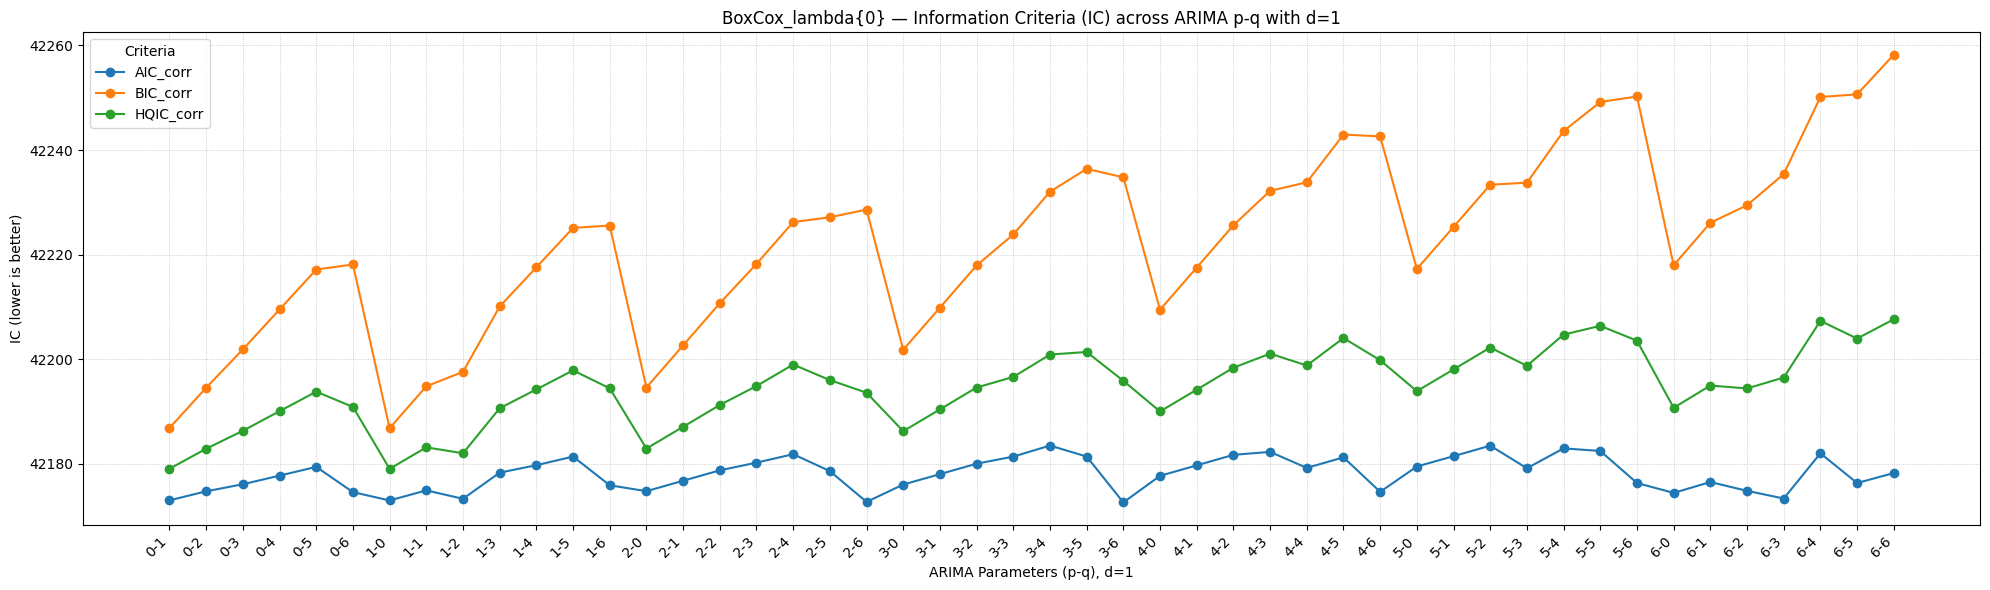

In [19]:
df = df_mdl_res_indep_all_metrics.copy()
df["p-q"] = df["p"].astype(str) + "-" + df["q"].astype(str)

# Subset (BoxCox λ=0, d=1) e ordenar por p e q
subset = df[(df["serie"] == "BoxCox_lambda{0}") & (df["d"] == 1)].copy()
subset = subset.sort_values(["p", "q"])

# Aggregate the lowest Information Criterion (IC) values for each "p,q" pair
agg = subset.groupby("p-q", as_index=False)[["AIC_corr", "BIC_corr", "HQIC_corr"]].min()

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(agg["p-q"], agg["AIC_corr"],  marker="o", linestyle="-", label="AIC_corr")
ax.plot(agg["p-q"], agg["BIC_corr"],  marker="o", linestyle="-", label="BIC_corr")
ax.plot(agg["p-q"], agg["HQIC_corr"], marker="o", linestyle="-", label="HQIC_corr")

ax.set_title("BoxCox_lambda{0} — Information Criteria (IC) across ARIMA p-q with d=1")
ax.set_xlabel("ARIMA Parameters (p-q), d=1")
ax.set_ylabel("IC (lower is better)")
ax.legend(title="Criteria", loc="best")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<u>__Conclusions:__</u>
- The global minimum of the IC occurs at a simple model, ARIMA(1,1,0);
- The metrics of BIC and HQIC consistently favor simpler models and agree on the same winner, on the other hand, AIC sometimes prefers a slightly more complex alternative;
- As p or q increases, all criteria increase, thus illustrating the model complexity penalty. BIC is the metric that increases the most, HQIC increases less sharply, and AIC increases very gently.

    ---------------------------------------------------------------------------------------------------------------------------

    6.4.4 In-Sample Fit Comparison (AIC, BIC, HQIC) of the Top 5 ARIMA Models under Box–Cox λ = 0

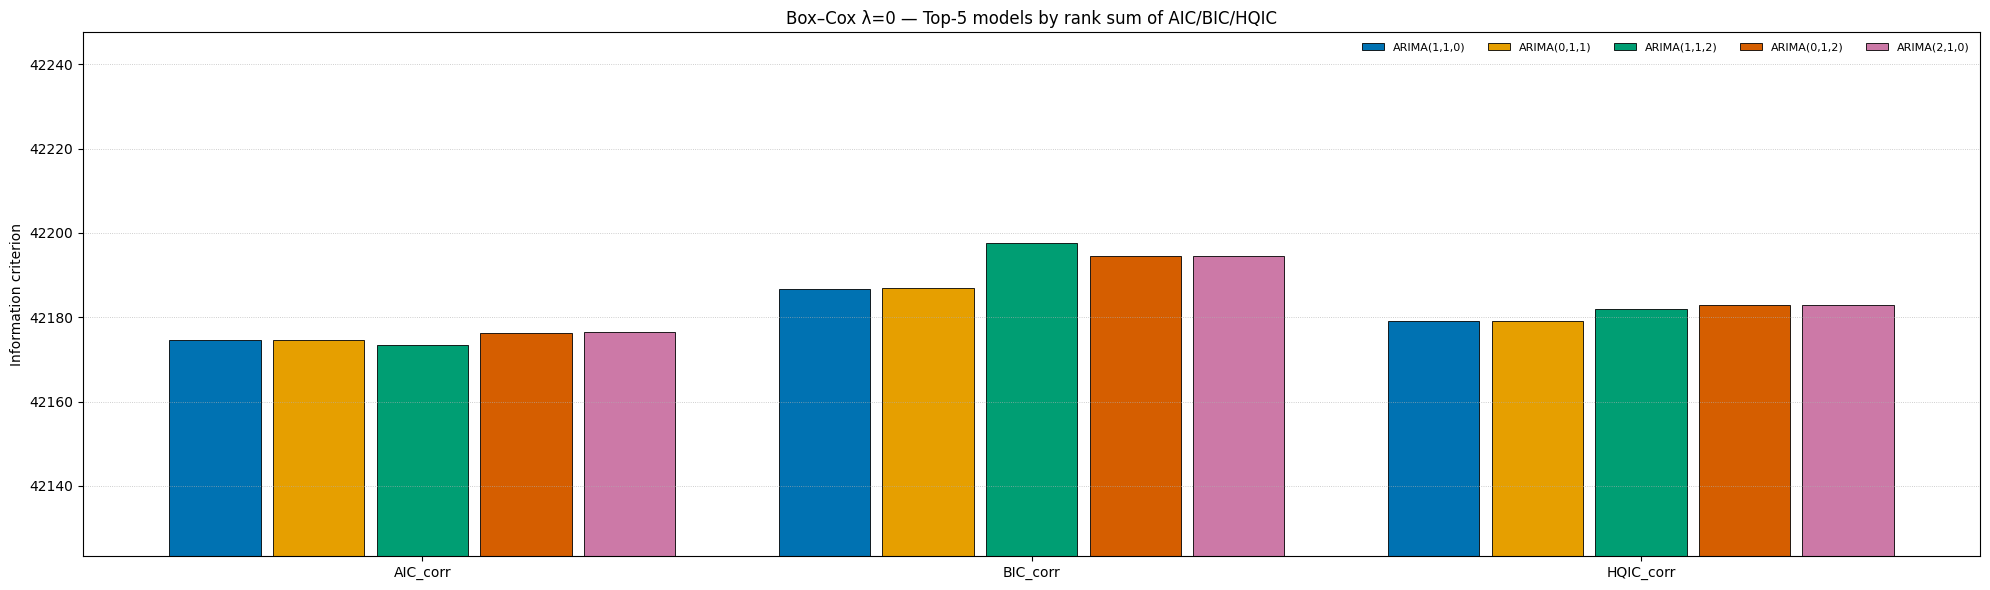

In [20]:
# Metrics to plot
metrics = ("AIC_corr", "BIC_corr", "HQIC_corr")
pad = 50

# Colorblind palette
colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#000000"]

# Prepare Top-5 and readable labels
df0 = top5_models_bc0.copy().sort_values(["rank_sum", *metrics]).reset_index(drop=True)
df0["label"] = [f"ARIMA({int(p)},{int(d)},{int(q)})" for p, d, q in zip(df0["p"], df0["d"], df0["q"])]

# Map a color per unique model label
all_labels = df0["label"].unique()
color_map = {label: colors[i % len(colors)] for i, label in enumerate(all_labels)}

# One x-position per metric (AIC/BIC/HQIC)
x_pos = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(20, 6))

# Number of models, bar width and spacing
models = len(df0)
w = 0.15
spacing = 0.02

# Y limits from its own values
vals = df0[list(metrics)].to_numpy().ravel()
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
ax.set_ylim(vmin - pad, vmax + pad)

# Draw grouped bars per metric
for i, row in df0.iterrows():
    row_vals = [row[m] for m in metrics]
    # center the cluster of bars around each metric position
    bar_offset = (i - (models - 1) / 2) * (w + spacing)
    color = color_map[row["label"]]
    ax.bar(x_pos + bar_offset, row_vals, width=w, label=row["label"],
           color=color, edgecolor="#000000", linewidth=0.6)

# X axis, labels, title, grid
ax.set_xticks(x_pos, metrics)
ax.set_ylabel("Information criterion")
ax.set_title("Box–Cox λ=0 — Top-5 models by rank sum of AIC/BIC/HQIC")
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.8)

# Legend without duplicates
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), ncol=5, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


<u>__Conclusions:__</u>
- Again, it can be seen that, the best ranked model is ARIMA(1,1,0);

    ---------------------------------------------------------------------------------------------------------------------------

    6.4.5 In-Sample Fitting: Baseline vs Top 5 ARIMA under Box–Cox λ=0

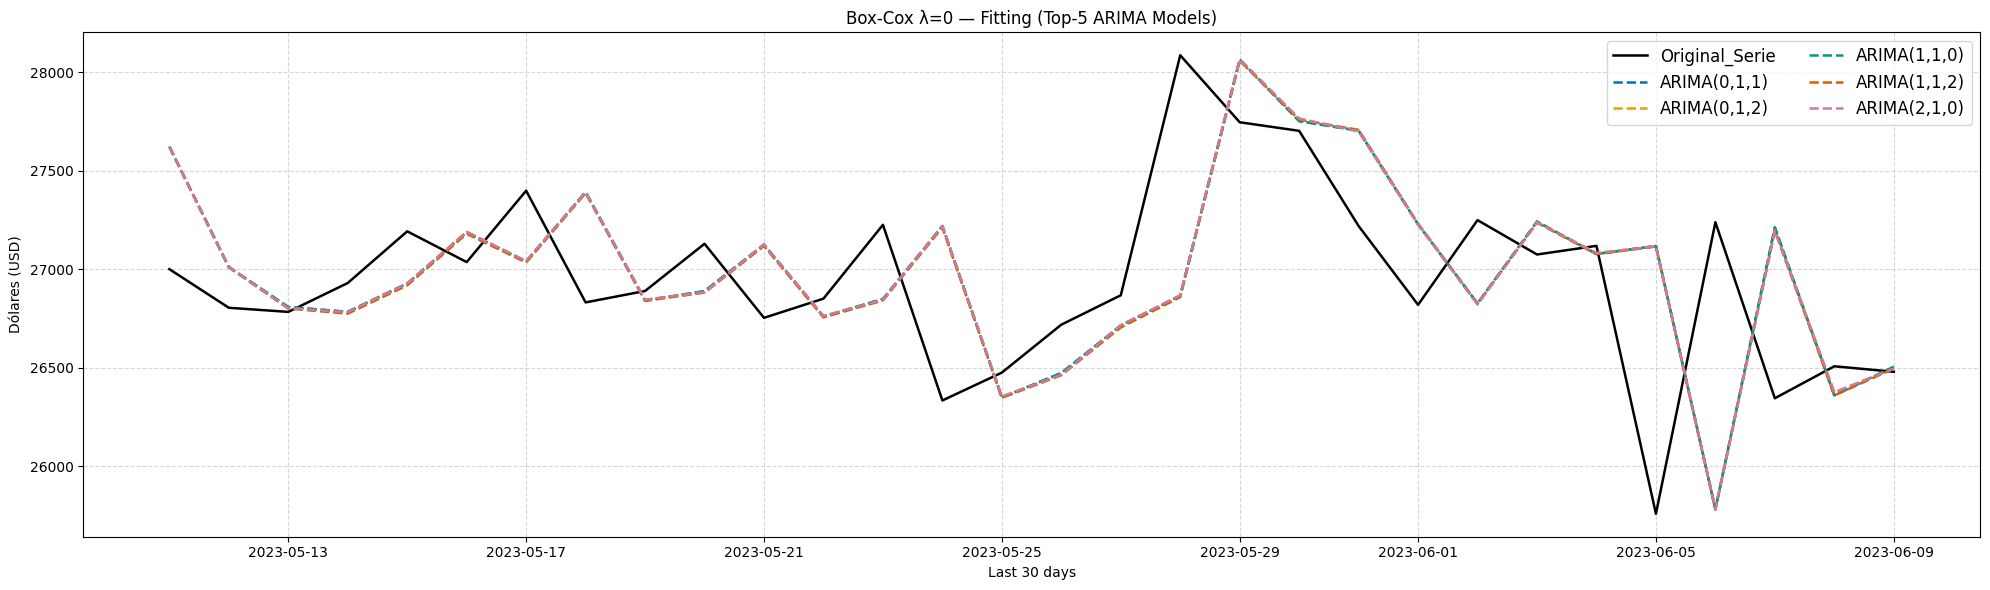

In [21]:
sel_cols = ["p", "d", "q", "trend"]

# Filter "fitted_original" of top-5 ARIMA models for Box-Cox λ = 0
top5_models_bc0_obj = {(int(r.p), int(r.d), int(r.q), str(r.trend)) for r in top5_models_bc0[sel_cols].drop_duplicates().itertuples(index=False)}
df_tmp_bc0 = df_mdl_res_indep_all.copy()
mask_bc0_obj = df_tmp_bc0.apply(lambda r: (r.p, r.d, r.q, r.trend) in top5_models_bc0_obj, axis=1)
mask_serie_bc0 = df_tmp_bc0["serie"].eq("BoxCox_lambda{0}")
top5_models_bc0_fitvalues = df_tmp_bc0.loc[mask_serie_bc0 & mask_bc0_obj, ["serie"] + sel_cols + ["fitted_original"]].copy()

# Retrieve the index of the original series for alignment in plots
temp = df_mdl_res_indep_all[df_mdl_res_indep_all["serie"] == "Original_serie"].iloc[0]
serie_original = temp["fitted_original"]
index_original = serie_original.index

palette = ["#0072B2", "#E69F00", "#009E73", "#D55E00",  "#CC79A7"]

# Define function to plot top-5 ARIMA model fits
def plot_top5(top5_models_fitvalues, titulo):

    plt.figure(figsize=(20, 6))

    # Plot the last 30 values of the original training series in black
    plt.plot(df_train_original[-30:], label= "Original_Serie", linewidth=1.8, color="#000000")

    # Assign one unique color per model
    colors = palette[:len(top5_models_fitvalues)]

    # Plot each fitted ARIMA model
    for (row, color) in zip(top5_models_fitvalues.itertuples(index=False), colors):
        fitted_series = row.fitted_original[-30:]
        label = f"ARIMA({int(row.p)},{int(row.d)},{int(row.q)})"
        plt.plot(index_original[-30:], fitted_series, label=label, linewidth=1.8, color=color, linestyle="--")

    plt.title(titulo)
    plt.xlabel("Last 30 days")
    plt.ylabel("Dólares (USD)")
    plt.legend(fontsize=12, ncol=2)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Generate plots for Box-Cox λ = 0
plot_top5(top5_models_bc0_fitvalues, "Box-Cox λ=0 — Fitting (Top-5 ARIMA Models)")

<u>__Conclusions:__</u>
- Lower order models, fit the original series well, suggesting stability and a lower risk of overfitting;
- The Top 5 fitted curves almost coincide with the original serie.

    ---------------------------------------------------------------------------------------------------------------------------

---

# 7. Forecasting Performance and Model Selection

    7.1 Out-of-Sample Forecast Values of the Top 5 ARIMA Models

In [22]:
# Filter "forecast_original" of top-5 ARIMA models for Box-Cox λ = 0
top5_models_bc0_forecast = df_tmp_bc0.loc[mask_serie_bc0 & mask_bc0_obj, ["serie"] + sel_cols + ["forecast_original"]].copy()

def df_forecast(df_models: pd.DataFrame):
    """
    Build a forecast DataFrame with one row per ARIMA model, replacing time indices by sequential horizon labels (h=1, ..., h=15).

    Parameters
    ----------
    df_models (pd.DataFrame): DataFrame containing ARIMA model outputs.

    Returns
    -------
    df_res (pd.DataFrame): DataFrame of forecasts where, each row corresponds to one ARIMA model, columns are labeled h=1, up to the 
    length of forecast.
    """
    rows = []

    # Build dictionary of a model name for a forecast vector
    for _, r in df_models.iterrows():
        # Extract basic model info
        serie = r["serie"]
        model = f"ARIMA({int(r['p'])},{int(r['d'])},{int(r['q'])})"
        trend = r["trend"]

        # Clean forecasts and ensure numeric 1D array
        fc = np.asarray(pd.Series(r["forecast_original"]).astype(float).to_numpy()).ravel()

        # Store as dictionary
        row = {"serie": serie, "model": model, "trend": trend}
        row.update({f"h={i+1}": fc[i] for i in range(len(fc))})
        rows.append(row)

    df_fc = pd.DataFrame(rows)

    return df_fc

df_top5_models_bc0_fc = df_forecast(top5_models_bc0_forecast)

display_table(df_top5_models_bc0_fc.head(5), "Forecast Error by Horizon — Box-Cox λ=0 (Top-5 ARIMA Models)")


Forecast Error by Horizon — Box-Cox λ=0 (Top-5 ARIMA Models)
╒════╤══════════════════╤══════════════╤═════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤════════════╕
│    │      serie       │    model     │  trend  │    h=1     │    h=2     │    h=3     │    h=4     │    h=5     │    h=6     │    h=7     │    h=8     │    h=9     │    h=10    │    h=11    │    h=12    │    h=13    │    h=14    │       h=15 │
╞════╪══════════════════╪══════════════╪═════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │    n    │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.8229 │ 26480.

    7.2 Out-of-Sample Forecast Errors (Bias) of the Top 5 ARIMA Models

In [23]:
def df_bias_errors(df_forecast: pd.DataFrame, y_true: pd.Series):
    """
    Compute forecast bias errors for multiple horizons h=1, ..., h=n.

    Parameters
    ----------
    df_forecast (pd.DataFrame): DataFrame containing forecasts per horizon h=1, ..., h=n.
    y_true (pd.Series): Series containing the true observed values.
    
    Returns
    -------
    pd.DataFrame: Table with model metadata and forecast errors per horizon.
    """

    # Identify forecast columns corresponding to horizons h=1, ..., h=n
    h_cols = sorted([c for c in df_forecast.columns if str(c).startswith("h=")], key=lambda s: int(s.split("=")[1]))
    h = len(h_cols)

    # Prepare true values and predicted
    y_ref = y_true.reset_index(drop=True).to_numpy(dtype=float)[:h]
    pred  = df_forecast[h_cols].to_numpy(dtype=float)

    # Compute forecast errors
    err = pred - y_ref
    df_err = pd.DataFrame(err, index=df_forecast.index, columns=h_cols)

    # Combine model metadata (serie, model, trend) with error columns
    meta = [c for c in ("serie", "model", "trend") if c in df_forecast.columns]
    result = pd.concat([df_forecast[meta], df_err], axis=1) if meta else df_err
    return result

df_top5_md_bc0_fc_error = df_bias_errors(df_top5_models_bc0_fc, df_test_original["Close"])

display_table(df_top5_md_bc0_fc_error.head(5), "Forecast Errors of Top5 Fitting ARIMA Models:")


Forecast Errors of Top5 Fitting ARIMA Models:
╒════╤══════════════════╤══════════════╤═════════╤══════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤══════════╤══════════╤══════════╤═══════════╤════════════╤════════════╤════════════╤════════════╤════════════╕
│    │      serie       │    model     │  trend  │   h=1    │   h=2    │   h=3    │   h=4    │    h=5    │   h=6    │   h=7    │   h=8    │   h=9    │   h=10    │    h=11    │    h=12    │    h=13    │    h=14    │       h=15 │
╞════╪══════════════════╪══════════════╪═════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │    n    │ 629.5827 │ 540.6549 │ 578.3229 │ 562.0944 │ 1356.1471 │ 904.4284 │ 153.3600 │ -29.8529 │ 144.6100 │ -370.2064 │ -1846.6654 │ -3546.4740 │ -3431.4584 │ -4214.6459 │ -4067.8724 │
├────┼──────────────────┼──────────────┼─

    7.3 Multi-Horizon Out-of-Sample Forecasting Performance

In [24]:
def forecast_metrics(df_errors: pd.DataFrame, y_true: pd.Series, horizons=(1, 5, 7, 15)):
    """
    Compute forecast error metrics for selected horizons and return the Top-N models by APE.

    Parameters
    ----------
    df_errors (pd.DataFrame): DataFrame containing forecasts bias errors per horizon h=1, ..., h=n.
    y_true (pd.Series): Series containing the true observed values.
    horizons (tuple[int][default (1, 5, 7, 15)]): Horizons to evaluate.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary where each key is 'h=...' and the value is a DataFrame with the Top-N models by APE.
    """
    y_true_arr = y_true.reset_index(drop=True).to_numpy(dtype=float)

    # Basic checks
    meta_cols = [c for c in ("serie", "model", "trend") if c in df_errors.columns]
    results = {}

    for h in horizons:
        col = f"h={h}"

        # Extract error column for the horizon
        err = df_errors[col].astype(float).to_numpy()

        # True value at this horizon
        y_h = float(y_true_arr[h - 1])

        # Avoid division issues in APE
        if np.isfinite(y_h) and y_h != 0:
            ape = (np.abs(err) / np.abs(y_h)) * 100.0
        else:
            ape = 99999

        h_errors_metrics = pd.DataFrame({"bias error": err, "SE": err**2, "RSE": np.sqrt(err**2), "AE": np.abs(err), "APE": ape})

        # Attach metadata (model, trend, ...)
        h_errors_metrics = pd.concat([df_errors[meta_cols].reset_index(drop=True), h_errors_metrics], axis=1)

        # Store under a clean key
        results[col] = h_errors_metrics.sort_values("APE", ascending=True).reset_index(drop=True)

    return results


top5_bc0_results = forecast_metrics(df_top5_md_bc0_fc_error, df_test_original["Close"], horizons=(1, 5, 7, 15))

df_bc0_h1_top5_forecast  = top5_bc0_results.get("h=1")
df_bc0_h5_top5_forecast  = top5_bc0_results.get("h=5")
df_bc0_h7_top5_forecast  = top5_bc0_results.get("h=7")
df_bc0_h15_top5_forecast = top5_bc0_results.get("h=15")

display_table(df_bc0_h1_top5_forecast,  "Forecast Error Metrics — Box-Cox λ=0 (h=1, ordered by APE)")
display_table(df_bc0_h5_top5_forecast,  "Forecast Error Metrics — Box-Cox λ=0 (h=5, ordered by APE)")
display_table(df_bc0_h7_top5_forecast,  "Forecast Error Metrics — Box-Cox λ=0 (h=7, ordered by APE)")
display_table(df_bc0_h15_top5_forecast, "Forecast Error Metrics — Box-Cox λ=0 (h=15, ordered by APE)")


Forecast Error Metrics — Box-Cox λ=0 (h=1, ordered by APE)
╒════╤══════════════════╤══════════════╤═════════╤══════════════╤═════════════╤══════════╤══════════╤════════╕
│    │      serie       │    model     │  trend  │  bias error  │     SE      │   RSE    │    AE    │    APE │
╞════╪══════════════════╪══════════════╪═════════╪══════════════╪═════════════╪══════════╪══════════╪════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(1,1,2) │    n    │   622.1525   │ 387073.6720 │ 622.1525 │ 622.1525 │ 2.4067 │
├────┼──────────────────┼──────────────┼─────────┼──────────────┼─────────────┼──────────┼──────────┼────────┤
│ 1  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │    n    │   629.5827   │ 396374.3161 │ 629.5827 │ 629.5827 │ 2.4354 │
├────┼──────────────────┼──────────────┼─────────┼──────────────┼─────────────┼──────────┼──────────┼────────┤
│ 2  │ BoxCox_lambda{0} │ ARIMA(1,1,0) │    n    │   629.6117   │ 396410.8350 │ 629.6117 │ 629.6117 │ 2.4355 │
├────┼──────────────────┼──────────────┼─────────┼──

In order to better visualize and understand the occurrence of unusually low APE values for the 7 day forecast horizon, a graph was created for the best model of each dataset.

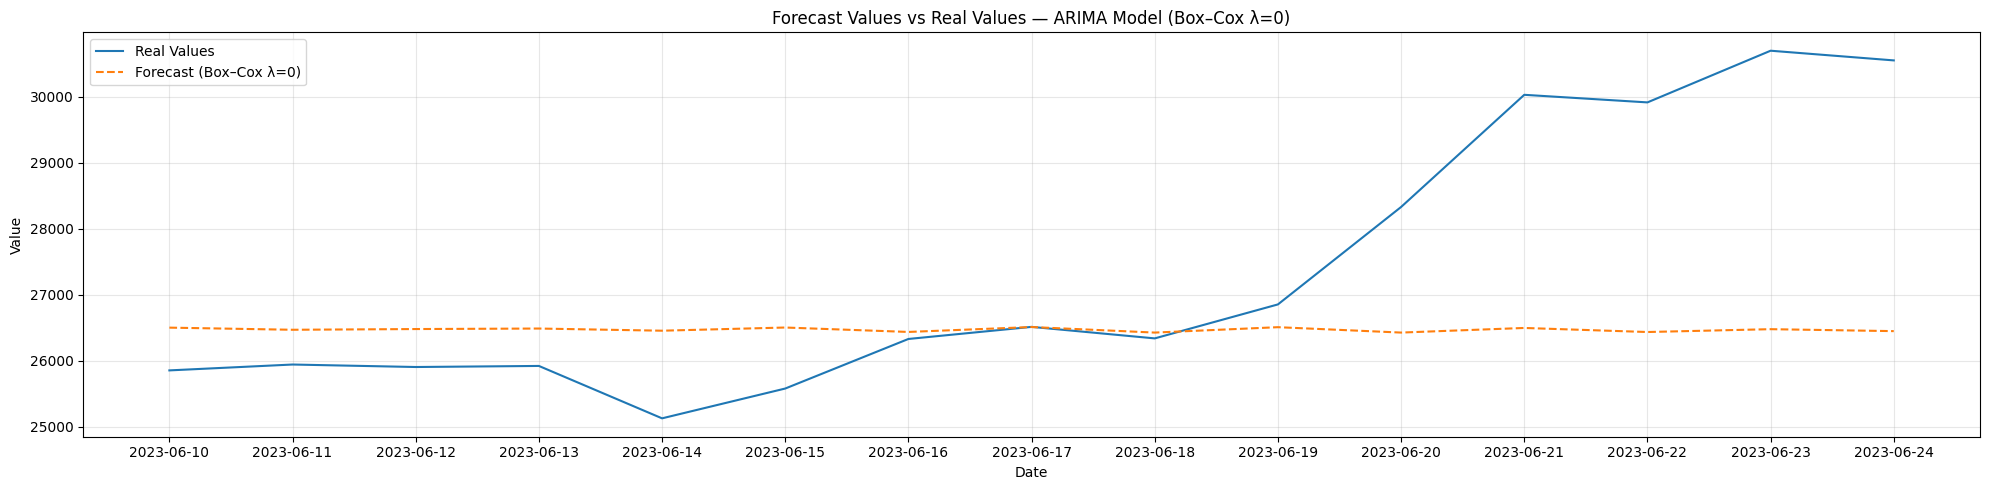

In [25]:
def plot_forecast_vs_actual(forecast_values: pd.Series, real_values: pd.Series, title: str, forecast_label: str):
    """
    Plot forecasted and actual values over a specified horizon.

    Parameters
    ----------
    forecast_values (pd.Series): Forecasted values for the last horizont time steps.
    real_values (pd.Series)    : Series containing the true observed values.
    title (str)                : Title displayed on the plot.
    forecast_label (str)       : Label used to identify the forecast line in the legend.

    Returns
    -------
    Displays a time series plot comparing actual and forecasted values aligned by date.
    """
    forecast = pd.Series(forecast_values).astype(float)
    
    real = pd.Series(real_values).astype(float)
    real = real.iloc[:len(forecast)]
    real = real.asfreq("D")

    real.index = pd.to_datetime(real.index)
    forecast.index = real.index[:len(forecast)]

    df_plot = pd.concat({"Real values": real, "Forecast values": forecast}, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(20,5))
    ax.plot(df_plot.index, df_plot["Real values"],     label= "Real Values")
    ax.plot(df_plot.index, df_plot["Forecast values"], label= f"{forecast_label}", linestyle="--")

    # Daily ticks
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(df_plot.index, rotation=0)

    ax.set_title(f"Forecast Values vs Real Values — {title}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_forecast_vs_actual(forecast_values = df_mdl_obj_bc0["forecast_original"][167],
                        real_values     = df_test_original["Close"],
                        title           = "ARIMA Model (Box–Cox λ=0)",
                        forecast_label  = "Forecast (Box–Cox λ=0)")

<u>__Conclusions:__</u>

Through the presented plots, it becomes clear why the APE is so low for the h=7 horizon, however, it is most likely to be just a coincidence. For this reason, the MAPE will be calculated using the rolling window method, thus allowing for a more accurate estimation of the error for each dataset.

    ---------------------------------------------------------------------------------------------------------------------------

    7.4. Rolling-Window Out-of-Sample Forecast Errors

In [26]:
def rolling_window_errors(serie_train: pd.Series, serie_test: pd.Series, true_serie_test: pd.Series, window_length: int | None, 
                          horizon: int | None, csv_dir: str | None, df_mdl_rw_all_metrics: pd.DataFrame, step: int = 15, num_windows: int = 1):
    """
    Compute rolling-window forecast errors and performance metrics (bias, MAE, RMSE, MAPE) for multiple ARIMA models and horizons h=1, ..., h=n.

    Parameters
    ----------
    serie_train (pd.Series)                    : Training portion of the time series.
    serie_test (pd.Series)                     : Test portion of the transformed series used for forecasting.
    true_serie_test (pd.Series)                : Original time series, of test series for error evaluation.
    window_length (int | None)                 : Length of each rolling window for model training.
    horizon (int)                              : Forecast horizon (maximum number of steps ahead).
    csv_dir (str | None)                       : Directory path to save the output CSV files.
    df_mdl_res_indep_all_metrics (pd.DataFrame): DataFrame with ARIMA order specifications (p, d, q, trend).
    step (int)                                 : Step size by which the rolling window moves forward each iteration.
    num_windows (int)                          : Number of rolling windows to evaluate.

    Returns
    -------
    df_fc_metrics (pd.DataFrame): Mean bias errors per model and horizon, Table with all forecast metrics (bias, MAE, RMSE, MAPE) per model and horizon
    """
    # Keep train length and build full series (train+test) for window slicing
    serie   = pd.concat([serie_train, serie_test])
    n_train = len(serie_train)

    # Align true test to test length (tail align) and reset index
    true_serie_test = true_serie_test.iloc[-len(serie_test):].reset_index(drop=True)
    assert len(true_serie_test) == len(serie_test), "true_serie_test and serie_test should have the same lenght."

    # Rolling window length and step
    window_length = len(serie_train) if window_length is None else window_length
    step          = step if step is not None else max(1, (len(serie_test) - 15) // max(1, num_windows))

    # Horizon requested: if None, use what's available given num_windows and step
    horizon_req = len(serie_test) - (num_windows - 1) * step if horizon is None else int(horizon)
    horizon_req = int(max(1, horizon_req))

    # Save rule: if user gave horizon -> standard filenames; else -> bestARIMA filenames
    saveflag = True if horizon < 16 else False

    # Models (p,d,q,trend) to evaluate
    orders_list = list(df_mdl_rw_all_metrics[["p", "d", "q", "trend"]].itertuples(index=False, name=None))

    # List of wide error DataFrames (one per window)
    per_window_error_tables = []
    # List of dicts (one row per origin and per h, per model)
    long_records = []

    for window in range(num_windows):
        # Origin inside the test block
        origin_test = window * step
        if origin_test >= len(serie_test):
            break

        # Indices for training slice on the full series
        end_test           = n_train + origin_test
        train_window_end   = end_test
        train_window_start = train_window_end - window_length
        serie_temp         = serie.iloc[train_window_start:train_window_end]
        serie_temp.name    = serie_train.name

        # Effective horizon in this window = min(requested, remaining test, remaining true)
        remaining_test  = len(serie_test) - origin_test
        remaining_true  = len(true_serie_test) - origin_test
        H_w = int(max(0, min(horizon_req, remaining_test, remaining_true)))
        if H_w == 0:
            break

        # Fit models for this window and request H_w-step forecasts
        results_models = optimal_arima_parameters(serie_temp, horizon=horizon, orders=orders_list, hide_progress=True)

        # Build a compact list of rows with forecasts for df_forecast()
        rows = []
        for res in results_models:
            rows.append({"serie":             getattr(serie_train, "name", "Unknown"),
                         "p":                 res["p"],
                         "d":                 res["d"],
                         "q":                 res["q"],
                         "trend":             res["trend"],
                         "horizon":           H_w,
                         "forecast_original": res["forecast_original"]})
        forecast_series_temp = pd.DataFrame(rows)

        # Expand forecasts into columns h=1,...,H_w
        df_fc = df_forecast(forecast_series_temp)
        h_cols_all = sorted([c for c in df_fc.columns if str(c).startswith("h=")], key=lambda s: int(s.split("=")[1]))
        h_cols_use = [c for c in h_cols_all if int(c.split("=")[1]) <= H_w]
        
        keep_cols  = [c for c in ("serie","model","trend") if c in df_fc.columns] + h_cols_use
        df_fc = df_fc[keep_cols]

        # True values aligned for H_w
        true_window_vals = true_serie_test.iloc[origin_test : origin_test + H_w].reset_index(drop=True)

        # Compute per-horizon bias errors (forecast - true)
        df_window_errors = df_bias_errors(df_fc, true_window_vals)
        df_window_errors.insert(0, "origin_idx", end_test)
        df_window_errors.insert(1, "origin_date", serie.index[end_test])
        
        # Add ground truth columns (y_true_h=k) for metric computations
        for h in range(1, H_w + 1):
            df_window_errors[f"y_true_h={h}"] = float(true_window_vals.iloc[h-1])

        per_window_error_tables.append(df_window_errors)
    
        # Build LONG records: one row per model, per horizon, per origin
        for _, r in df_fc.iterrows():
            for h in range(1, H_w + 1):
                long_records.append({"origin_idx" : end_test,
                                     "origin_date": serie.index[end_test],
                                     "serie"      : r["serie"],
                                     "model"      : r["model"],
                                     "trend"      : r["trend"],
                                     "h"          : h,
                                     "y_pred"     : float(r[f"h={h}"]),
                                     "y_true"     : float(true_window_vals.iloc[h-1])})

        # Stack windows (errors) and build long DF
        df_total = pd.concat(per_window_error_tables, axis=0, ignore_index=True)

    df_long = pd.DataFrame(long_records)  # <- long table for DM/CW and plots

    # Identify error columns h=1, ..., h=n to aggregate by model
    h_cols = sorted([c for c in df_total.columns if str(c).startswith("h=")], key=lambda s: int(s.split("=")[1]))
    
    # Grouping keys that define a model identity
    group_cols = [c for c in ("serie", "model", "trend") if c in df_total.columns]

    # Mean bias per horizon across windows
    df_mean_errors = (df_total.groupby(group_cols, as_index=False)[h_cols]
                              .mean(numeric_only=True)
                              .sort_values(group_cols)
                              .reset_index(drop=True))

    # Full metrics per model and horizon (bias, MAE, RMSE, MAPE)
    recs = []
    for keys, g in df_total.groupby(group_cols, sort=False):
        kd = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        for col in h_cols:
            h = int(col.split("=")[1])
            if col not in g.columns: 
                continue
            e = g[col].astype(float).to_numpy()
            y = g.get(f"y_true_h={h}", pd.Series(np.nan, index=g.index)).astype(float).to_numpy()
            recs.append({**kd,
                         "h": h,
                         "bias": float(np.nanmean(e)),
                         "MAE":  float(np.nanmean(np.abs(e))),
                         "RMSE": float(np.sqrt(np.nanmean(e**2))),
                         "MAPE": float(np.nanmean(np.abs(e) / (np.abs(y))) * 100.0)})

    df_fc_metrics = (pd.DataFrame(recs).sort_values(group_cols + ["h"]).reset_index(drop=True))

    if csv_dir:
        os.makedirs(csv_dir, exist_ok=True)
        base = getattr(serie_train, 'name', 'serie')
        model = orders_list
        if saveflag:
            df_mean_errors.to_csv(os.path.join(csv_dir, f"{base}_ARIMA{model}_mean_errors.csv"), index=False)
            df_fc_metrics.to_csv(os.path.join(csv_dir, f"{base}_ARIMA{model}_metrics_long.csv"), index=False)
            df_long.to_csv(os.path.join(csv_dir, f"{base}_ARIMA{model}_rolling_forecasts_long.csv"), index=False)
        else:
            df_mean_errors.to_csv(os.path.join(csv_dir, f"{base}_bestARIMA{model}_mean_errors.csv"), index=False)
            df_fc_metrics.to_csv(os.path.join(csv_dir, f"{base}_bestARIMA{model}_metrics_long.csv"), index=False)
            df_long.to_csv(os.path.join(csv_dir, f"{base}_bestARIMA{model}_rolling_forecasts_long.csv"), index=False)

    return df_mean_errors, df_fc_metrics, df_long

In [27]:
# Directory to store forecast and error results
csv_dir_fc = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\arima_models_mean_forecast_values"
os.makedirs(csv_dir_fc, exist_ok=True)

results_mean_errors = {}

# Series
serie_train = df_series_train["BoxCox_lambda{0}"].copy()
serie_train.name = "BoxCox_lambda{0}"
serie_test  = df_series_test["BoxCox_lambda{0}"].copy()

# Extract (p,d,q) from "model" column
orders = df_top5_md_bc0_fc_error["model"].str.extract(r"ARIMA\((\d+),(\d+),(\d+)\)")
orders.columns = ["p", "d", "q"]
orders = orders.astype(int)

# Attach trend
df_orders_all = pd.concat([orders.reset_index(drop=True), df_top5_md_bc0_fc_error["trend"].reset_index(drop=True)], axis=1)
df_orders_all.columns = ["p", "d", "q", "trend"]

# Duration per iteration: 6 hours approx.
for row in df_orders_all.itertuples(index=False):
    p, d, q, trend = row
    model_key = f"ARIMA({p},{d},{q})_trend={trend}"
    print(f"Rolling Window for Model: {model_key}")

    df_order_row = pd.DataFrame([{"p": p, "d": d, "q": q, "trend": trend}])

    # Compute rolling-window
    df_mean_errors, df_fc_metrics, df_long = rolling_window_errors(serie_train           = serie_train,
                                                                   serie_test            = serie_test,
                                                                   true_serie_test       = df_series_test["Original_serie"],
                                                                   window_length         = len(serie_train),
                                                                   horizon               = 15,
                                                                   csv_dir               = csv_dir_fc,
                                                                   df_mdl_rw_all_metrics = df_order_row,
                                                                   step                  = 21,
                                                                   num_windows           = 30)

    results_mean_errors[model_key] = {"Bias mean_errors": df_mean_errors,
                                      "Forecast metrics": df_fc_metrics,
                                      "long": df_long}
    print(">"*100)
    print("\n")

Rolling Window for Model: ARIMA(0,1,1)_trend=n
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>


Rolling Window for Model: ARIMA(0,1,2)_trend=n
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>


Rolling Window for Model: ARIMA(1,1,0)_trend=n
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>


Rolling Window for Model: ARIMA(1,1,2)_trend=n
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>


Rolling Window for Model: ARIMA(2,1,0)_trend=n
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>




    ---------------------------------------------------------------------------------------------------------------------------

    7.5 Rolling-Window Forecast Error Metrics of the Top 5 ARIMA Models

In [28]:
df_bc0_top5_forecast_rw_011 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(0, 1, 1, 'n')]_metrics_long.csv"))
df_bc0_top5_forecast_rw_012 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(0, 1, 2, 'n')]_metrics_long.csv"))
df_bc0_top5_forecast_rw_110 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(1, 1, 0, 'n')]_metrics_long.csv"))
df_bc0_top5_forecast_rw_112 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(1, 1, 2, 'n')]_metrics_long.csv"))
df_bc0_top5_forecast_rw_211 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(2, 1, 0, 'n')]_metrics_long.csv"))

df_bc0_top5_forecast_rw_mdls = pd.concat([df_bc0_top5_forecast_rw_011,
                                          df_bc0_top5_forecast_rw_012,
                                          df_bc0_top5_forecast_rw_110,
                                          df_bc0_top5_forecast_rw_112,
                                          df_bc0_top5_forecast_rw_211])

df_bc0_h1_top5_forecast_rw  = df_bc0_top5_forecast_rw_mdls[df_bc0_top5_forecast_rw_mdls["h"] == 1].sort_values("MAPE")
df_bc0_h5_top5_forecast_rw  = df_bc0_top5_forecast_rw_mdls[df_bc0_top5_forecast_rw_mdls["h"] == 5].sort_values("MAPE")
df_bc0_h7_top5_forecast_rw  = df_bc0_top5_forecast_rw_mdls[df_bc0_top5_forecast_rw_mdls["h"] == 7].sort_values("MAPE")
df_bc0_h15_top5_forecast_rw = df_bc0_top5_forecast_rw_mdls[df_bc0_top5_forecast_rw_mdls["h"] == 15].sort_values("MAPE")

display_table(df_bc0_h1_top5_forecast_rw,  "Forecast Error Metrics — Box-Cox λ=0 (h=1, ordered by APE)")
display_table(df_bc0_h5_top5_forecast_rw,  "Forecast Error Metrics — Box-Cox λ=0 (h=5, ordered by APE)")
display_table(df_bc0_h7_top5_forecast_rw,  "Forecast Error Metrics — Box-Cox λ=0 (h=7, ordered by APE)")
display_table(df_bc0_h15_top5_forecast_rw, "Forecast Error Metrics — Box-Cox λ=0 (h=15, ordered by APE)")


Forecast Error Metrics — Box-Cox λ=0 (h=1, ordered by APE)
╒════╤══════════════════╤══════════════╤═════════╤═════╤══════════╤══════════╤══════════╤════════╕
│    │      serie       │    model     │  trend  │  h  │   bias   │   MAE    │   RMSE   │   MAPE │
╞════╪══════════════════╪══════════════╪═════════╪═════╪══════════╪══════════╪══════════╪════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │    n    │  1  │ -81.5295 │ 318.2951 │ 468.7201 │ 0.5912 │
├────┼──────────────────┼──────────────┼─────────┼─────┼──────────┼──────────┼──────────┼────────┤
│ 0  │ BoxCox_lambda{0} │ ARIMA(1,1,0) │    n    │  1  │ -81.8913 │ 318.6767 │ 468.7277 │ 0.5919 │
├────┼──────────────────┼──────────────┼─────────┼─────┼──────────┼──────────┼──────────┼────────┤
│ 0  │ BoxCox_lambda{0} │ ARIMA(1,1,2) │    n    │  1  │ -80.2571 │ 322.5755 │ 478.7596 │ 0.5991 │
├────┼──────────────────┼──────────────┼─────────┼─────┼──────────┼──────────┼──────────┼────────┤
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,2) │    n    

<u>__Conclusions:__</u>

The results obtained by the models for the Box-Cox λ=0 transformed series clearly show an increase in forecasting error across the different horizons. These results are in line with what would be expected, as the longer the forecasting horizon, the more difficult it becomes to accurately predict the value. All models display stability in their error values across horizons, which provides robustness to the results.<br>
As mentioned, an increase in error metrics is observed as the forecasting horizon increases, ranging from approximately 0.60% for h=1, 3.7% for h=5, 4.0% for h=7.8, and 8% for h=15. It can be observed that for all horizons, with the exception of h=5, the ARIMA(1,1,0) model presents the lowest error metric values, which supports its selection as a potentially best performing model, as it indicates robustness and stability in forecasting capability.<br>
It can also be observed that all bias error values are negative, suggesting that the models consistently underestimate the true values, with this effect becoming more pronounced as the forecasting horizon increases. Nevertheless, overall, the results show consistency in their forecasting capability.

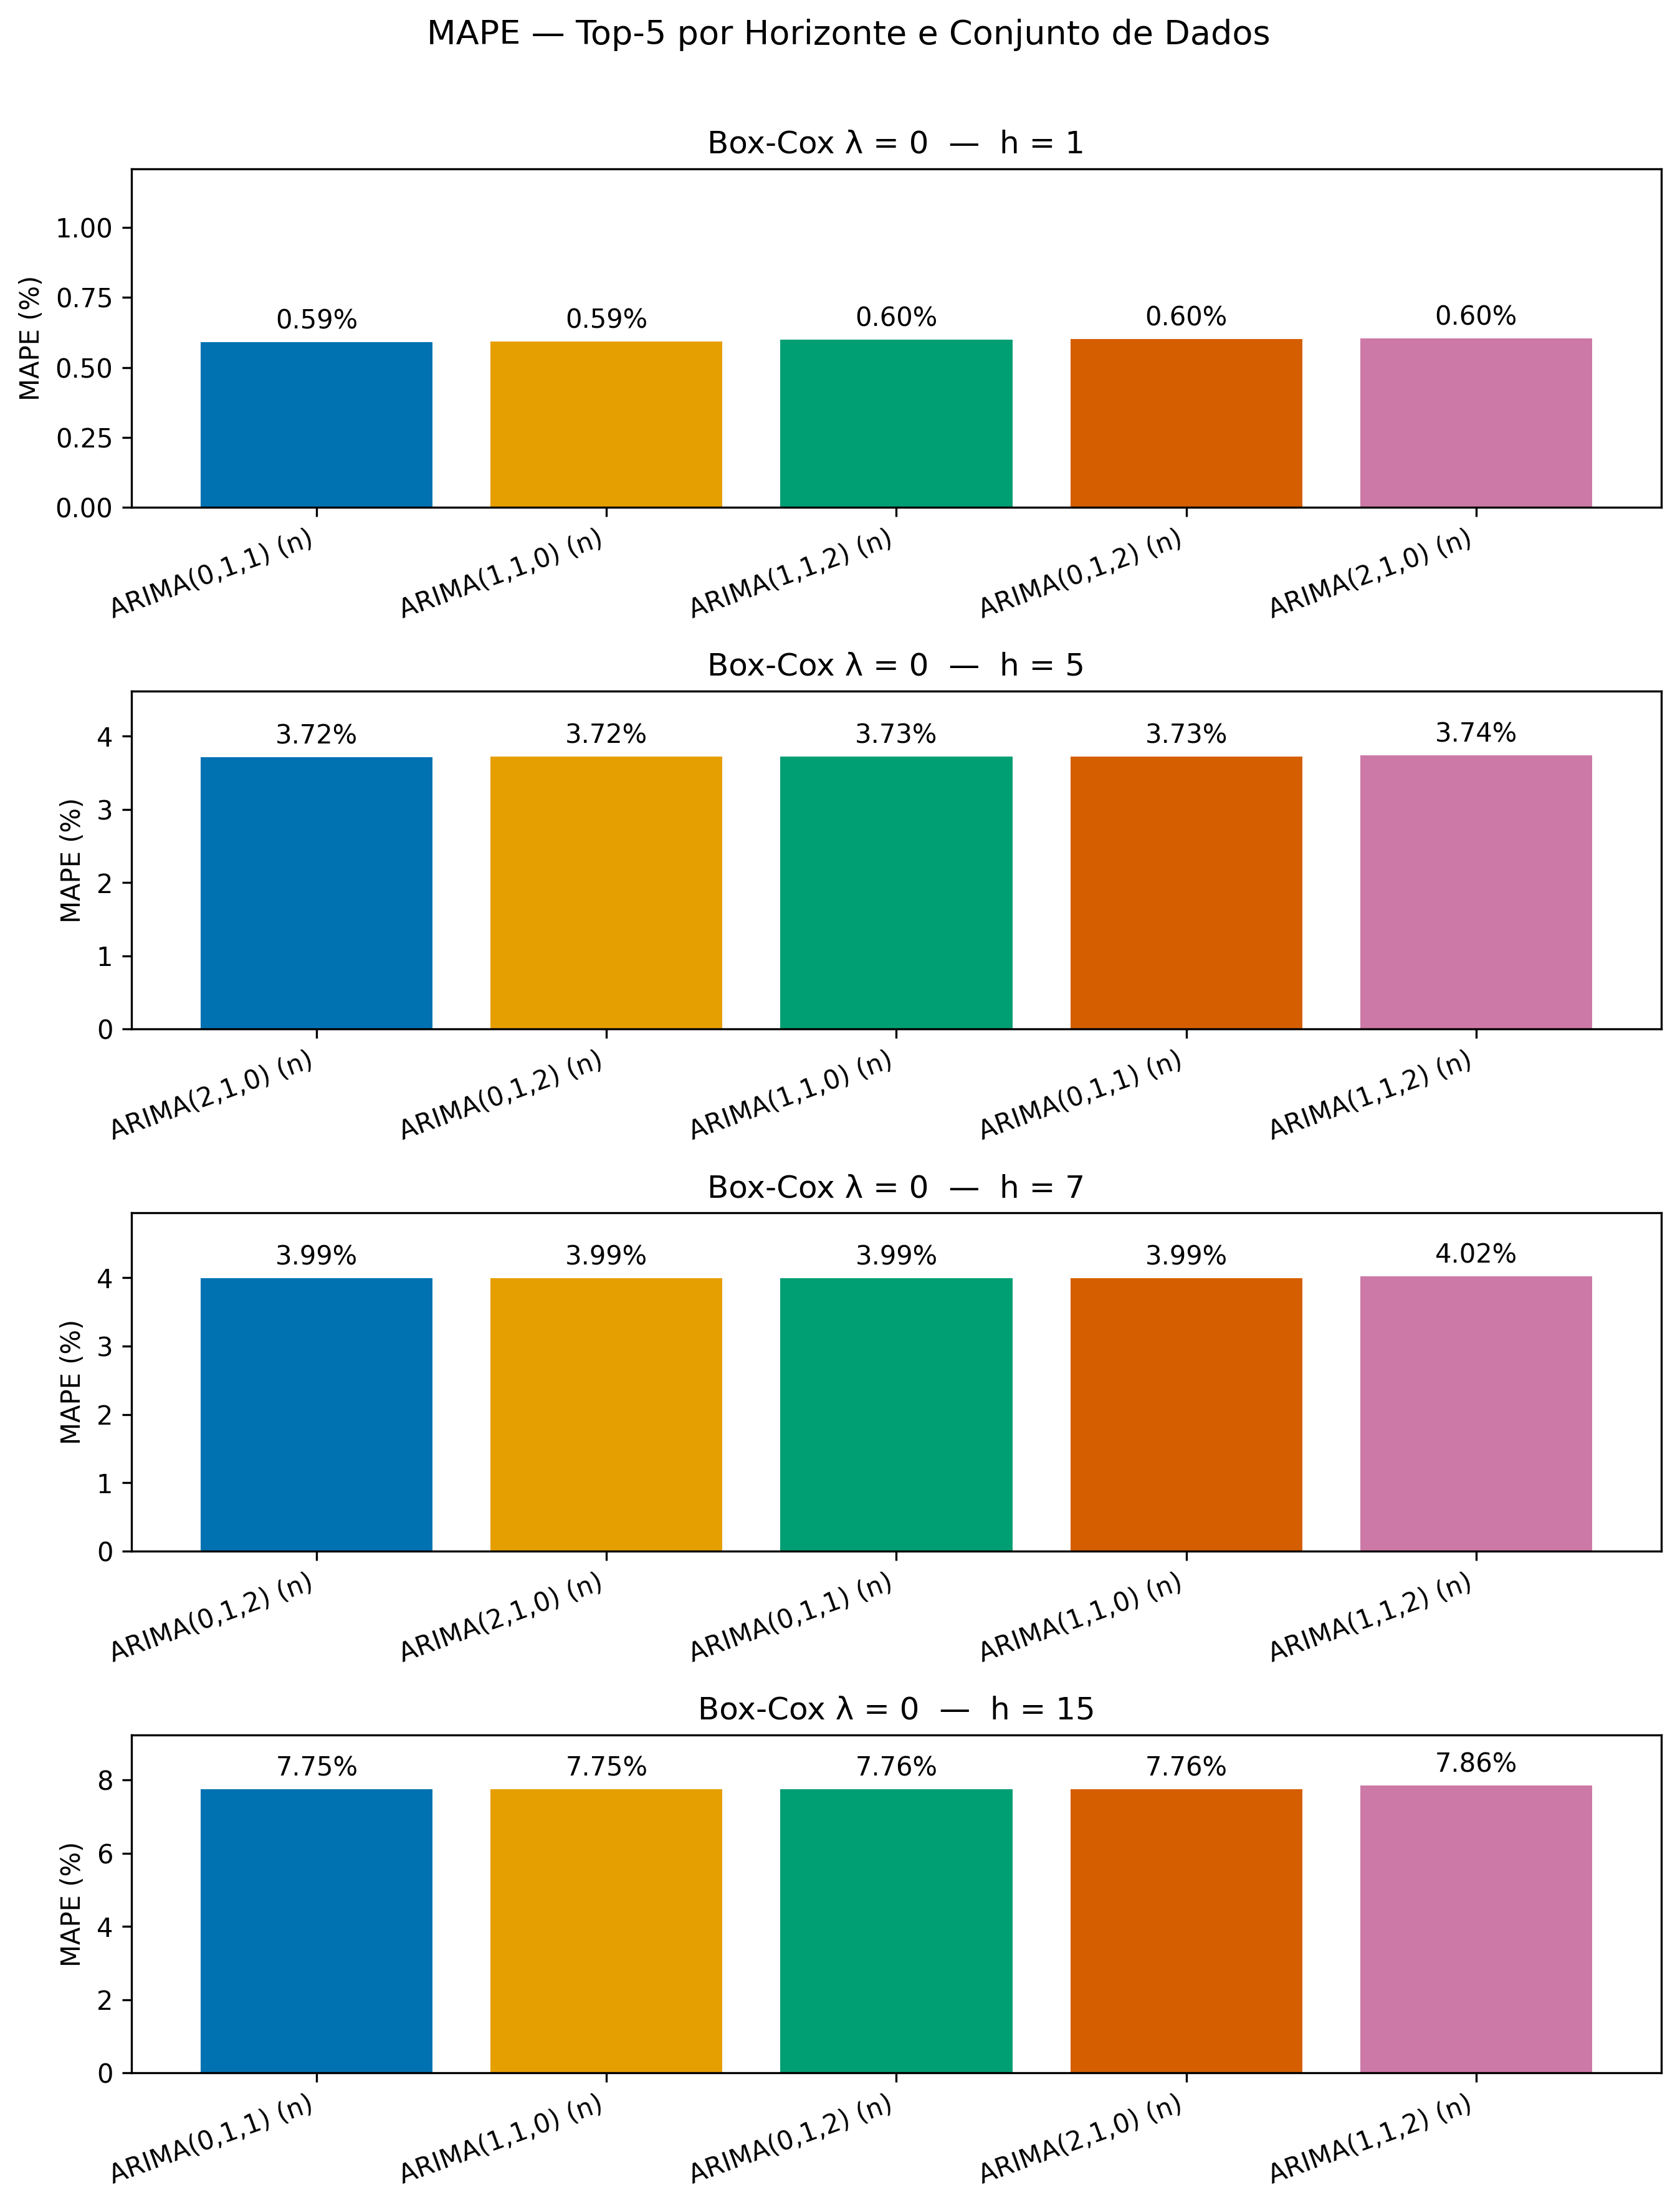

In [29]:
palette = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]

def bar_plot_mape(ax, df_top5, titulo, ymax, show_values=True):
    trend = df_top5.get("trend", pd.Series([""] * len(df_top5))).astype(str).fillna("")
    labels = df_top5["model"].astype(str) + np.where(trend.str.len() > 0, " (" + trend + ")", "")

    values = pd.to_numeric(df_top5["MAPE"], errors="coerce").to_numpy(dtype=float)
    colors = [palette[i % len(palette)] for i in range(len(values))]

    bars = ax.bar(range(len(values)), values, color=colors)

    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("MAPE (%)")
    ax.set_title(titulo)
    ax.set_ylim(0, ymax * 1.10)

    if show_values:
        for rect, val in zip(bars, values):
            ax.annotate(f"{val:.2f}%",
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom")

def plot_mape_4x1(series_title: str,
                 df_h1: pd.DataFrame, df_h5: pd.DataFrame, df_h7: pd.DataFrame, df_h15: pd.DataFrame,
                 show_values: bool = True):

    dfs = [df_h1, df_h5, df_h7, df_h15]
    h_labels = ["h = 1", "h = 5", "h = 7", "h = 15"]

    fig, axs = plt.subplots(4, 1, figsize=(9, 12), dpi=300)
    fig.suptitle("MAPE — Top-5 por Horizonte e Conjunto de Dados", fontsize=13)

    # Define ymax per row (as in your example: each panel scaled to its own level)
    for r, df_top5 in enumerate(dfs):
        ax = axs[r]

        ymax = float(pd.to_numeric(df_top5["MAPE"], errors="coerce").max())
        ymax = round(ymax + 0.5, 1)  # small headroom, adjust if you want

        titulo = f"{series_title}  —  {h_labels[r]}"
        bar_plot_mape(ax, df_top5, titulo, ymax=ymax, show_values=show_values)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- CALL (use your 4 dataframes) ---
plot_mape_4x1(series_title="Box-Cox λ = 0",
              df_h1=df_bc0_h1_top5_forecast_rw,
              df_h5=df_bc0_h5_top5_forecast_rw,
              df_h7=df_bc0_h7_top5_forecast_rw,
              df_h15=df_bc0_h15_top5_forecast_rw,
              show_values=True)


<u>__Conclusions:__</u>

The MAPE plots for the forecasting horizons clearly illustrate the expected increase in forecast error as the prediction horizon becomes longer. This pattern reflects the growing uncertainty associated with longer-term predictions. For the Box-Cox λ=0 transformed series, all Top-5 ARIMA models exhibit very similar MAPE values at each forecasting horizon, indicating a high degree of stability and robustness across model specifications. Despite the increase in error magnitude with the forecasting horizon, the relative differences between models remain marginal, suggesting that the predictive performance is largely driven by the horizon length rather than by the specific ARIMA configuration.

    7.6 Out-of-Sample Performance Summary and Model Selection

In [30]:
df_oos_summary = (df_bc0_top5_forecast_rw_mdls.groupby("model", as_index=False).agg(mean_mape=("MAPE", "mean"),std_mape=("MAPE", "std"))
                  .sort_values("mean_mape"))

display_table(df_oos_summary,"")
best_model = df_oos_summary.iloc[0]["model"]
print(f"Selected final model based on OOS performance: {best_model}")



╒════╤══════════════╤═════════════╤════════════╕
│    │    model     │  mean_mape  │   std_mape │
╞════╪══════════════╪═════════════╪════════════╡
│ 0  │ ARIMA(0,1,1) │   4.4958    │     2.1313 │
├────┼──────────────┼─────────────┼────────────┤
│ 2  │ ARIMA(1,1,0) │   4.4960    │     2.1314 │
├────┼──────────────┼─────────────┼────────────┤
│ 1  │ ARIMA(0,1,2) │   4.4973    │     2.1358 │
├────┼──────────────┼─────────────┼────────────┤
│ 4  │ ARIMA(2,1,0) │   4.4975    │     2.1360 │
├────┼──────────────┼─────────────┼────────────┤
│ 3  │ ARIMA(1,1,2) │   4.5313    │     2.1561 │
╘════╧══════════════╧═════════════╧════════════╛
Selected final model based on OOS performance: ARIMA(0,1,1)


    7.7 Temporal Stability of Out-of-Sample MAPE

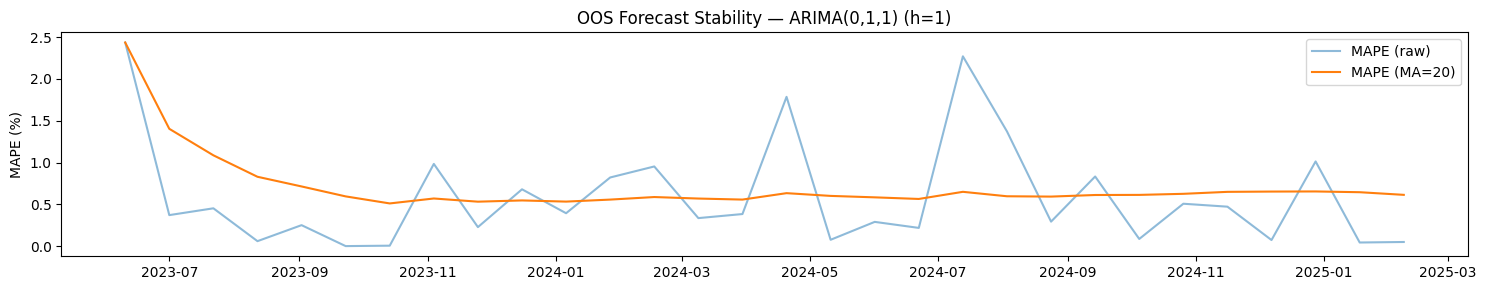

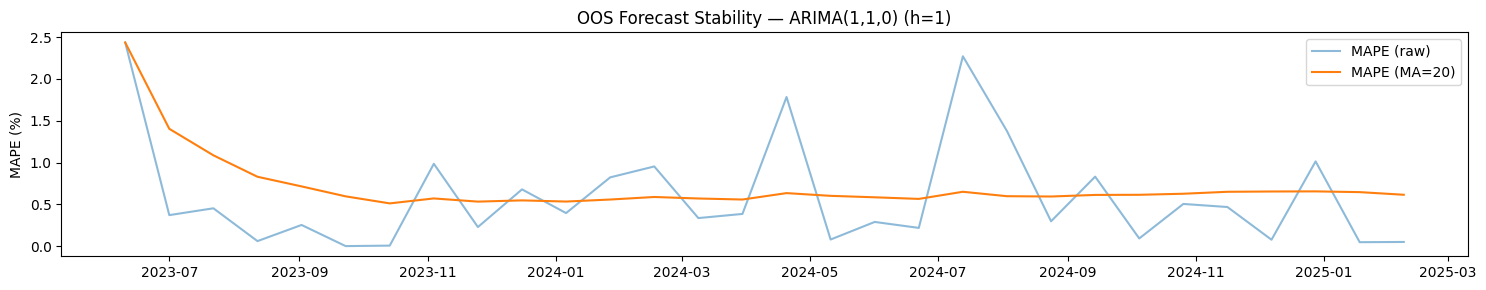

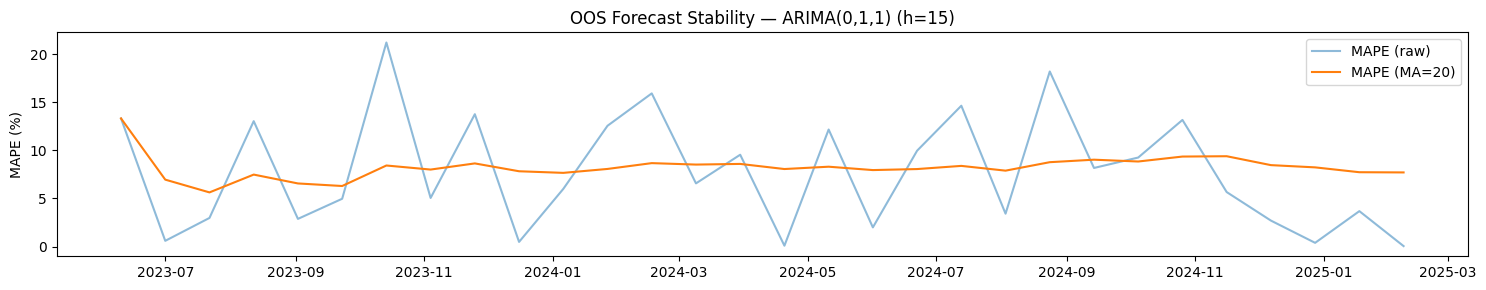

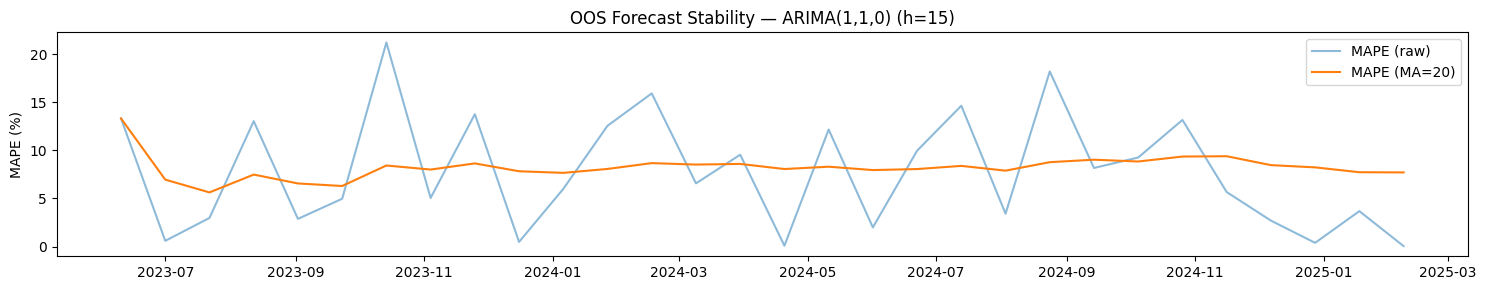

In [31]:
df_long_011 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(0, 1, 1, 'n')]_rolling_forecasts_long.csv"))
df_long_110 = pd.read_csv(os.path.join(csv_dir_fc, "BoxCox_lambda{0}_ARIMA[(1, 1, 0, 'n')]_rolling_forecasts_long.csv"))

def plot_oos_stability_mape(df_long, model, h=1, rolling_ma=20):
    """
    This function computes a MAPE value for each rolling-origin forecast, for a given ARIMA model and a fixed horizon h. 
    It then applies a moving-average smoothing(rolling mean) to highlight the underlying time-varying pattern of forecast accuracy.

    Parameters
    ----------
    df_long (pd.DataFrame): Long-format DataFrame containing rolling-origin forecasts
    model (str): Model identifier used in df_long['model']
    h (int[default=1]): Forecast horizon to evaluate
    rolling_ma (int[default=20]): Window length for the moving average (rolling mean) applied to the MAPE series.

    Returns
    -------
    Displays a Matplotlib plot of the raw per origin MAPE and its rolling mean.
    """
    # Filter to the selected model and horizon
    df = df_long[(df_long["model"] == model) & (df_long["h"] == h)].copy()
 
    df["origin_date"] = pd.to_datetime(df["origin_date"], errors="coerce")

    # Convert y_true and y_pred to numeric arrays
    y_true = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(df["y_pred"], errors="coerce").to_numpy(dtype=float)

    mape_raw = np.abs(y_true - y_pred) / np.abs(y_true) * 100.0

    s_mape_raw = pd.Series(mape_raw, index=df["origin_date"])

    # Smooth MAPE with a rolling (moving) average
    s_mape_raw_smoth = s_mape_raw.rolling(rolling_ma, min_periods=1).mean()

    plt.figure(figsize=(15,3))
    plt.plot(s_mape_raw, alpha=0.5, label="MAPE (raw)")
    plt.plot(s_mape_raw_smoth, label=f"MAPE (MA={rolling_ma})")
    plt.ylabel("MAPE (%)")
    plt.title(f"OOS Forecast Stability — {model} (h={h})")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_oos_stability_mape(df_long=df_long_011, model="ARIMA(0,1,1)", h=1, rolling_ma=20)
plot_oos_stability_mape(df_long=df_long_110, model="ARIMA(1,1,0)", h=1, rolling_ma=20)
plot_oos_stability_mape(df_long=df_long_011, model="ARIMA(0,1,1)", h=15, rolling_ma=20)
plot_oos_stability_mape(df_long=df_long_110, model="ARIMA(1,1,0)", h=15, rolling_ma=20)


The analysis shows that the performance of the ARIMA(0,1,1) and ARIMA(1,1,0) models is practically equivalent, both in terms of mean forecast error and error variability. The differences observed between the models are residual, suggesting that both exhibit a similar ability to model the conditional mean of the series.<br>
Given the absence of a clear advantage between the two best-performing models, the final selection is based on additional criteria, namely the principle of parsimony, in line with the classical Box–Jenkins approach (Box et al., 2015). Accordingly, the ARIMA(0,1,1) model is selected as benchmark model for subsequent analysis, with ARIMA(1,1,0) retained as a robustness alternative should limitations arise in the residual diagnostics.

    ---------------------------------------------------------------------------------------------------------------------------

---

# 8. Residual Diagnostics

    8.1 Residuals Over Time (Mean Dynamics)

In [32]:
# Model order
best_model_order = (0, 1, 1, "n")

# Best Model identified
best_df_mdl_obj = df_mdl_obj_bc0[(df_mdl_obj_bc0["p"]     == best_model_order[0]) &
                                 (df_mdl_obj_bc0["d"]     == best_model_order[1]) &
                                 (df_mdl_obj_bc0["q"]     == best_model_order[2]) &
                                 (df_mdl_obj_bc0["trend"] == best_model_order[3])]

best_mdl_obj_temp = optimal_arima_parameters(df_train_boxcox_0, orders= [best_model_order])
best_mdl_obj = best_mdl_obj_temp[0]["model"]
best_model_fit = best_df_mdl_obj["fitted_original"].iloc[0][1:]

# Best Model Residuals
best_model_residuals = best_df_mdl_obj["residuals"].iloc[0][1:]
best_model_residuals.index = df_train_boxcox_0.index[-len(best_model_residuals):]


The serie being evaluated is: BoxCox_lambda{0}


Grid Search: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.58it/s]


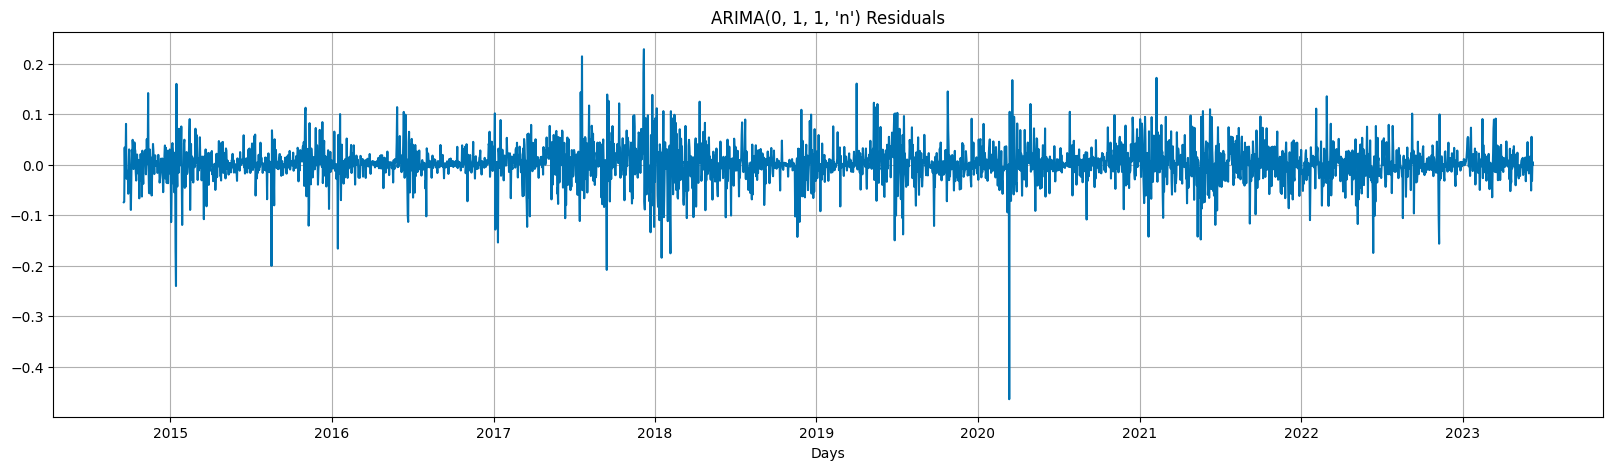


Residual's Mean and Variance
╒════╤═══════════════════╤═══════════════════════╕
│    │  Residual's Mean  │   Residual's Variance │
╞════╪═══════════════════╪═══════════════════════╡
│ 0  │      0.0013       │                0.0015 │
╘════╧═══════════════════╧═══════════════════════╛

Residuals of ARIMA(0,1,1,'n') — Box-Cox λ=0
╒════╤══════════════════╤══════════════╤═════════╤═════════╤═════════╤════════╤═════════╤════════╤════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤════════╤═════════╕
│    │      serie       │    model     │  trend  │   h=2   │   h=3   │  h=4   │   h=5   │  h=6   │  h=7   │   h=8   │   h=9   │  h=10   │  h=11   │  h=12   │  h=13   │  h=14  │    h=15 │
╞════╪══════════════════╪══════════════╪═════════╪═════════╪═════════╪════════╪═════════╪════════╪════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╪═════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │    n    │ -0.0746 │ -0.0737 │ 0.0338 │ -0.0244 │ 0.0079 │ 0.0805 │ -

In [33]:
# Plot model residuals
plt.figure(figsize=(20,5))
plt.plot(best_model_residuals.index, best_model_residuals.values, color="#0072B2")
plt.xlabel("Days")
plt.title("ARIMA" + str(best_model_order) + " Residuals")
plt.grid()
plt.show()

res_stat_info = pd.DataFrame({"Residual's Mean":     [round(np.mean(best_model_residuals),4)],
                              "Residual's Variance": [round(np.var(best_model_residuals),4)]})
display_table (res_stat_info, "Residual's Mean and Variance")

best_df_residuals_bc0          = df_residuals(best_df_mdl_obj)
best_df_residuals_bc0_analysis = df_residual_independence_analysis(best_df_mdl_obj)

display_table(best_df_residuals_bc0.iloc[:1, :17], "Residuals of ARIMA(0,1,1,'n') — Box-Cox λ=0")

<u>__Conclusions:__</u>

The residuals of the selected model indicate that the model is able to adequately capture the conditional mean of the data. With the average residual value being very close to zero (0.0013), it can be stated that there is no evidence of systematic error in the ARIMA(0,1,1) model. It is also observed that the residual variance is low, which suggests stability in the model’s behaviour.<br>
Through graphical analysis, as well as the inspection of the residual values table, it is observed that the residuals fluctuate around zero with no evident deterministic patterns. The plot further allows, from a visual perspective, the suggestion of compatibility with the hypothesis of residual stationarity. Some peaks of higher magnitude are also observed, which are consistent with periods of increased market volatility; however, these episodes are isolated and do not indicate persistent instability in the model.

    ---------------------------------------------------------------------------------------------------------------------------

    8.2 Residual Distribution (Histogram + KDE)

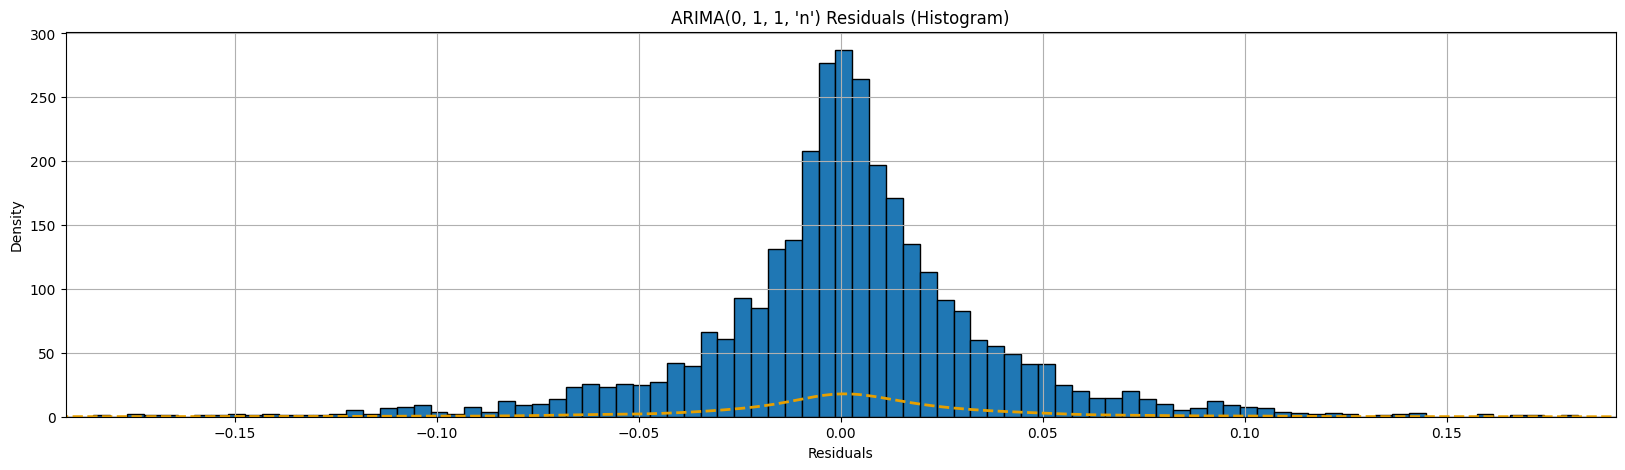


Skew and Kurtosis tests — Model ARIMA(0,1,1) Residuals
╒════╤══════════╤═════════════╤═══════════╤═══════════════════════════════════════════════════════════════╕
│    │   Test   │  Statistic  │  p-value  │ Decision                                                      │
╞════╪══════════╪═════════════╪═══════════╪═══════════════════════════════════════════════════════════════╡
│ 0  │ Kurtosis │   24.4459   │  0.0000   │ Non-normal kurtosis (reject H0) | Heavy tails (value=14.0490) │
├────┼──────────┼─────────────┼───────────┼───────────────────────────────────────────────────────────────┤
│ 1  │ Skewness │  -15.9123   │  0.0000   │ Asymmetric (reject H0) | Left-skewed (value=-0.7729)          │
╘════╧══════════╧═════════════╧═══════════╧═══════════════════════════════════════════════════════════════╛


In [34]:
# Compute number of bins
nbins, _ = freedman_diaconis_bins(best_model_residuals)

# Plot histogram of model residuals
plt.figure(figsize=(20,5))
plt.title("ARIMA" + str(best_model_order) + " Residuals (Histogram)")
hist_res = best_model_residuals.hist(bins=nbins, edgecolor="#000000")
best_model_residuals.plot(kind="kde", color="#E69F00", linewidth=2, linestyle="--")
plt.xlabel("Residuals")
limX = np.mean(best_model_residuals.values)+5*np.std(best_model_residuals.values)
plt.xlim((-limX, limX))
plt.grid()
plt.show()

skew_kurt = []
alpha = 0.05

# Kurtosis Test
k_stat, k_pval = kurtosistest(best_model_residuals)
kurtosis_val = kurtosis(best_model_residuals, fisher=False)
decision = "Normal kurtosis (fail to reject H0)" if k_pval > alpha else "Non-normal kurtosis (reject H0)"
tail = "Heavy tails" if kurtosis_val > 0 else "Light tails" if kurtosis_val < 0 else "Normal tails"
skew_kurt.append({"Test": "Kurtosis",
                  "Statistic": k_stat,
                  "p-value": k_pval,
                  "Decision": f"{decision} | {tail} (value={kurtosis_val:.4f})"})

# Skewness Test
s_stat, s_pval = skewtest(best_model_residuals)
skew_val = skew(best_model_residuals)
decision = "Symmetric (fail to reject H0)" if s_pval > alpha else "Asymmetric (reject H0)"
shape = "Right-skewed" if skew_val > 0 else ("Left-skewed" if skew_val < 0 else "Symmetric")
skew_kurt.append({"Test": "Skewness",
                  "Statistic": s_stat,
                  "p-value": s_pval,
                  "Decision": f"{decision} | {shape} (value={skew_val:.4f})"})

# DataFrames
df_skew_kurt = pd.DataFrame(skew_kurt, columns=["Test", "Statistic", "p-value", "Decision"])

# Display stationarity tables
display_table(df_skew_kurt, "Skew and Kurtosis tests — Model ARIMA(0,1,1) Residuals")

<u>__Conclusions:__</u>

Corroborating the information previously presented, the histogram shows that the residuals fluctuate around zero, with no evidence of systematic error in the model. However, the presence of pronounced tails and a deviation from the Gaussian shape are observed, suggesting non-normality in the residual distribution.<br>
This evidence is confirmed by the kurtosis and skewness tests, whose results are statistically significant. The high kurtosis indicates the presence of heavy tails, while the negative skewness value reveals left-skewness in the residual distribution. Both tests allow for the rejection of the null hypothesis of normality.<br>
These results indicate that, although the ARIMA model is able to adequately capture the conditional mean of the series, the residuals do not satisfy the normality assumption. This behaviour is consistent with what is documented in the literature for financial time series, where the occurrence of extreme values and asymmetric distributions is common. Thus, despite the model effectively capturing the mean dynamics, it is not capable of modelling the conditional variance, thereby justifying the need to resort to alternative models specifically designed for this purpose.

    8.3 Normality Diagnostics (Q–Q + Tests)

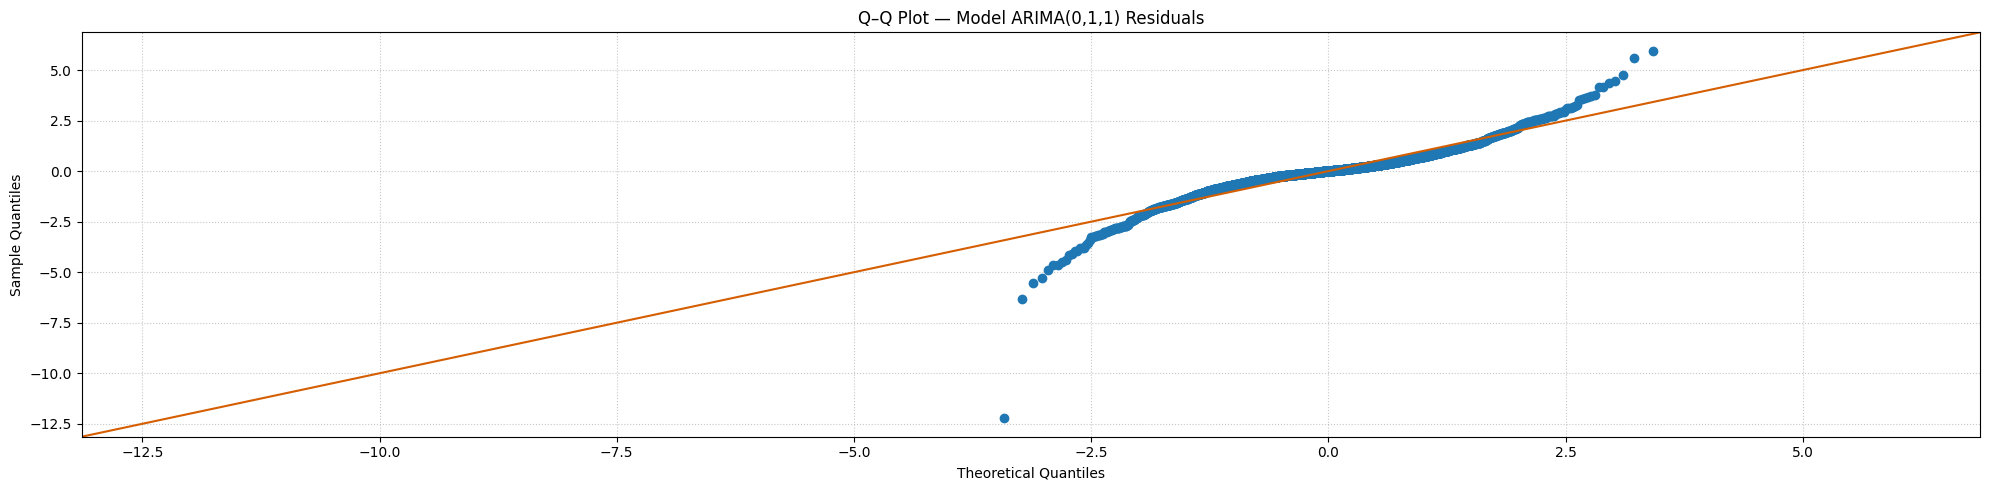


Normality tests — Model ARIMA(0,1,1) Residuals
╒════╤════════════════════╤═════════════╤═══════════╤═══════════════════════════╕
│    │        Test        │  Statistic  │  p-value  │ Decision                  │
╞════╪════════════════════╪═════════════╪═══════════╪═══════════════════════════╡
│ 0  │    Jarque-Bera     │ 16528.4563  │  0.0000   │ Non-normality (reject H0) │
├────┼────────────────────┼─────────────┼───────────┼───────────────────────────┤
│ 1  │ D’Agostino–Pearson │  850.8048   │  0.0000   │ Non-normality (reject H0) │
├────┼────────────────────┼─────────────┼───────────┼───────────────────────────┤
│ 2  │    Shapiro-Wilk    │   0.9050    │  0.0000   │ Non-normality (reject H0) │
╘════╧════════════════════╧═════════════╧═══════════╧═══════════════════════════╛


In [35]:
# Q–Q plot os best Model ARIMA(0,1,1) Residuals 
fig, ax = plt.subplots(figsize=(20,5))
qqplot(best_model_residuals, color="#0072B2", dist=stats.norm, line='45', fit=True, ax=ax)
ax.get_lines()[1].set_color("#D55E00")
ax.set_title('Q–Q Plot — Model ARIMA(0,1,1) Residuals')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

residuals_norm = []
alpha = 0.05

# Jarque-Bera Test
jb_stat, jb_pval = jarque_bera(best_model_residuals)
decision = "Normality (fail to reject H0)" if jb_pval > alpha else "Non-normality (reject H0)"
residuals_norm.append({"Test": "Jarque-Bera",
                       "Statistic": jb_stat,
                       "p-value": jb_pval,
                       "Decision": decision})

# D’Agostino–Pearson (global normality)
nt_stat, nt_pval = normaltest(best_model_residuals)
nt_dec = "Normality (fail to reject H0)" if nt_pval > alpha else "Non-normality (reject H0)"
residuals_norm.append({"Test": "D’Agostino–Pearson",
                       "Statistic": nt_stat,
                       "p-value": nt_pval,
                       "Decision": nt_dec})

# Shapiro–Wilk Test
shapiro_stat, shapiro_pval = shapiro(best_model_residuals)
decision = "Normality (fail to reject H0)" if shapiro_pval > alpha else "Non-normality (reject H0)"
residuals_norm.append({"Test": "Shapiro-Wilk",
                       "Statistic": shapiro_stat,
                       "p-value": shapiro_pval,
                       "Decision": decision})

# DataFrames
df_residuals_norm = pd.DataFrame(residuals_norm, columns=["Test", "Statistic", "p-value", "Decision"])

# Display stationarity tables
display_table(df_residuals_norm, "Normality tests — Model ARIMA(0,1,1) Residuals")

<u>__Conclusions:__</u>

The Q–Q plot strongly supports the evidence previously presented by the histogram. It is observed that the central quantiles are relatively well aligned with the reference line, however, pronounced deviations are evident in both the lower and upper quantiles, indicating the presence of heavy tails and extreme values.<br>
These results are corroborated by the Jarque–Bera, D’Agostino–Pearson, and Shapiro–Wilk tests, whose statistics are highly significant, leading to the rejection of the null hypothesis of normality in all cases. In this way, robust evidence is obtained that the residuals do not follow a Gaussian distribution.<br>
Taken together with the previous results, it is confirmed that, although the ARIMA model is able to adequately capture the conditional mean of the series, the residuals do not satisfy the normality assumption, making it necessary to apply a more appropriate class of models to address the volatility present in the series.

    8.4 Independence (ACF/PACF + Ljung–Box)

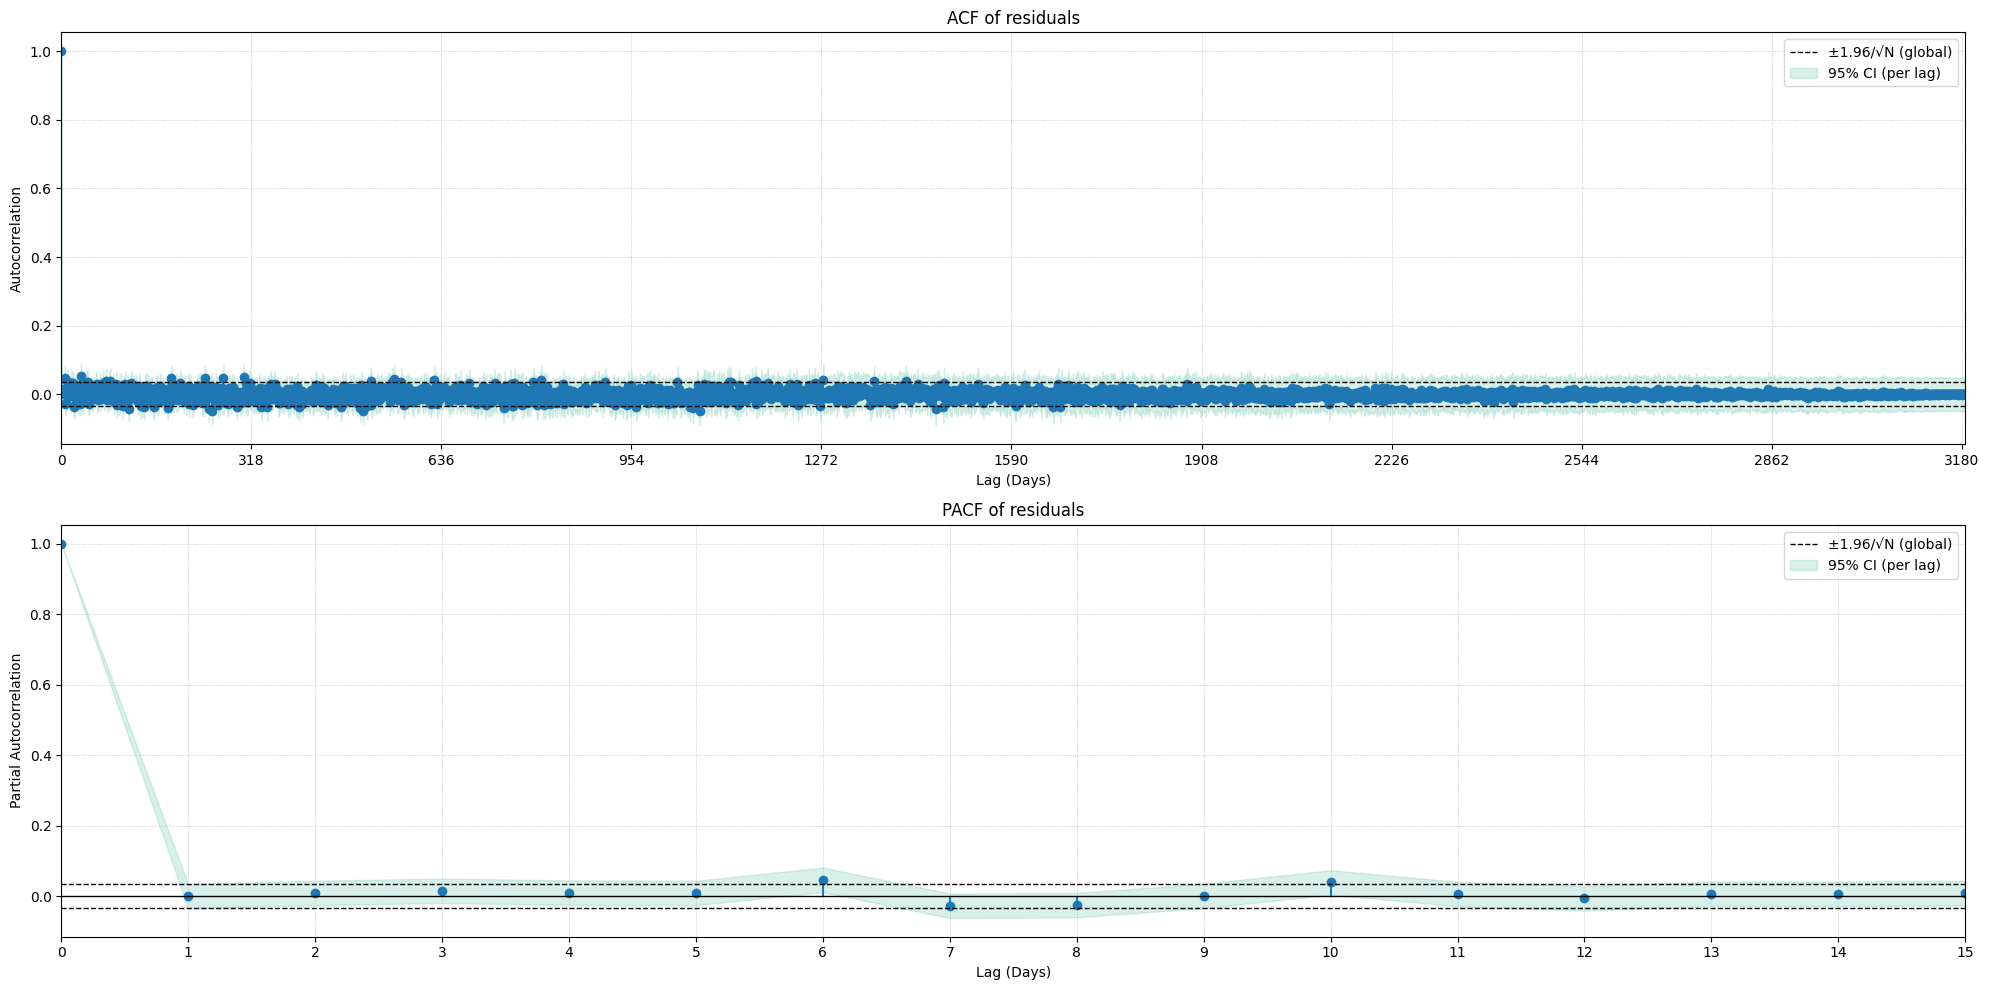


Ljung–Box Test on Model ARIMA(0,1,1) Residuals
╒════╤═══════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╕
│    │  Metric   │      1      │      2      │      3      │      4      │      5      │      6      │      7      │      8      │      9      │     10      │     11      │     12      │     13      │     14      │ 15          │
╞════╪═══════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0  │  LB_stat  │   0.0004    │   0.2637    │   0.9977    │   1.3214    │   1.5948    │   8.5594    │   10.8597   │   12.7419   │   12.7498   │   17.5061   │   17.6012   │   17.6638   │   17.7365   │   17.8377   │ 18.2046     │
├────┼───────────┼─────────────┼────

In [36]:
# ACF of residuals — Classical Confidence Interval
acf_vals, acf_conf = acf(best_model_residuals, nlags=len(best_model_residuals)-1, alpha=0.05, fft=False)
acf_lag_idx = np.arange(acf_vals.size)

# PACF of residuals
pacf_vals, pacf_conf = pacf(best_model_residuals, nlags=15, method="ywmle", alpha=0.05)
pacf_lag_idx = np.arange(len(pacf_vals))

fig, axes = plt.subplots(2, 1, figsize=(20, 10))
alpha_ci = 1.96 / np.sqrt(len(best_model_residuals))

# Plot ACF
axes[0].stem(acf_lag_idx, acf_vals, basefmt=" ")
axes[0].axhline(alpha_ci, color="#000000", linestyle="--", linewidth=1, label="±1.96/√N (global)")
axes[0].axhline(-alpha_ci, color="#000000", linestyle="--", linewidth=1)
axes[0].fill_between(acf_lag_idx, acf_conf[:,0], acf_conf[:,1], color="#009E73", alpha=0.15, label="95% CI (per lag)")
axes[0].set_xlim(0, acf_lag_idx.max())
axes[0].set_xticks(np.arange(0, acf_lag_idx.max()+1, max(1, acf_lag_idx.max()//10)))
axes[0].set_xlabel("Lag (Days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("ACF of residuals")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
axes[0].legend(loc="upper right")

# Plot PACF
axes[1].stem(pacf_lag_idx, pacf_vals, basefmt=" ")
axes[1].axhline(alpha_ci, color="#000000", linestyle="--", linewidth=1, label="±1.96/√N (global)")
axes[1].axhline(0, color="#000000", linewidth=1)
axes[1].axhline(-alpha_ci, color="#000000", linestyle="--", linewidth=1)
axes[1].fill_between(pacf_lag_idx, pacf_conf[:,0], pacf_conf[:,1], color="#009E73", alpha=0.15, label="95% CI (per lag)")
axes[1].set_xlim(0, pacf_lag_idx.max())
axes[1].set_xticks(np.arange(0, pacf_lag_idx.max()+1, max(1, pacf_lag_idx.max()//10)))
axes[1].set_xlabel("Lag (Days)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].set_title("PACF of residuals")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Ljung–Box test
resid = pd.Series(best_model_residuals).dropna().astype(float)

lb = acorr_ljungbox(resid, lags=15, return_df=True)
lb = lb.rename(columns={"lb_stat": "LB_stat", "lb_pvalue": "LB_pvalue"})
lb = lb.reset_index().rename(columns={"index": "lag"})

lb["Decision"] = np.where(lb["LB_pvalue"] > alpha, "Independent", "Autocorrelated")

# Select relevant columns
lb_results = lb[["lag", "LB_stat", "LB_pvalue", "Decision"]]

# Format numeric values to 4 decimal places
lb_results["LB_stat"]   = lb_results["LB_stat"].round(4)
lb_results["LB_pvalue"] = lb_results["LB_pvalue"].round(4)

# Remove index before transpose
lb_results = lb_results.set_index("lag").T

# Metrics column
lb_results.insert(0, "Metric", lb_results.index)
# Reset index
lb_results = lb_results.reset_index(drop=True)

display_table(lb_results, "Ljung–Box Test on Model ARIMA(0,1,1) Residuals")

<u>__Conclusions:__</u>

The autocorrelation (ACF) and partial autocorrelation (PACF) plots of the residuals reveal that there is no evidence of statistically significant temporal dependence. It is observed that the coefficients are very close to zero and, in general, lie within the confidence intervals, thus not exhibiting systematic autocorrelation patterns.<br>
These results reinforce the conclusions previously obtained, indicating that the ARIMA model adequately captures the dynamics of the conditional mean of the series, producing residuals consistent with a white noise process. Accordingly, there is no need to proceed with a further new specification of the ARIMA model, and any limitations identified are associated with other dimensions of the series, namely the modelling of conditional volatility.

    8.5 Conditional Heteroskedasticity (Squared Residuals + ARCH–LM)


ARCH LM of Residual Squared
╒════╤════════════════╤══════════════╤═══════════════╤═════════════╤════════════════════════════════════════════════╕
│    │  LM statistic  │  LM p-value  │  F statistic  │  F p-value  │ Decision                                       │
╞════╪════════════════╪══════════════╪═══════════════╪═════════════╪════════════════════════════════════════════════╡
│ 0  │    95.1018     │    0.0000    │    9.7697     │   0.0000    │ Reject homoskedasticity (ARCH effects present) │
╘════╧════════════════╧══════════════╧═══════════════╧═════════════╧════════════════════════════════════════════════╛


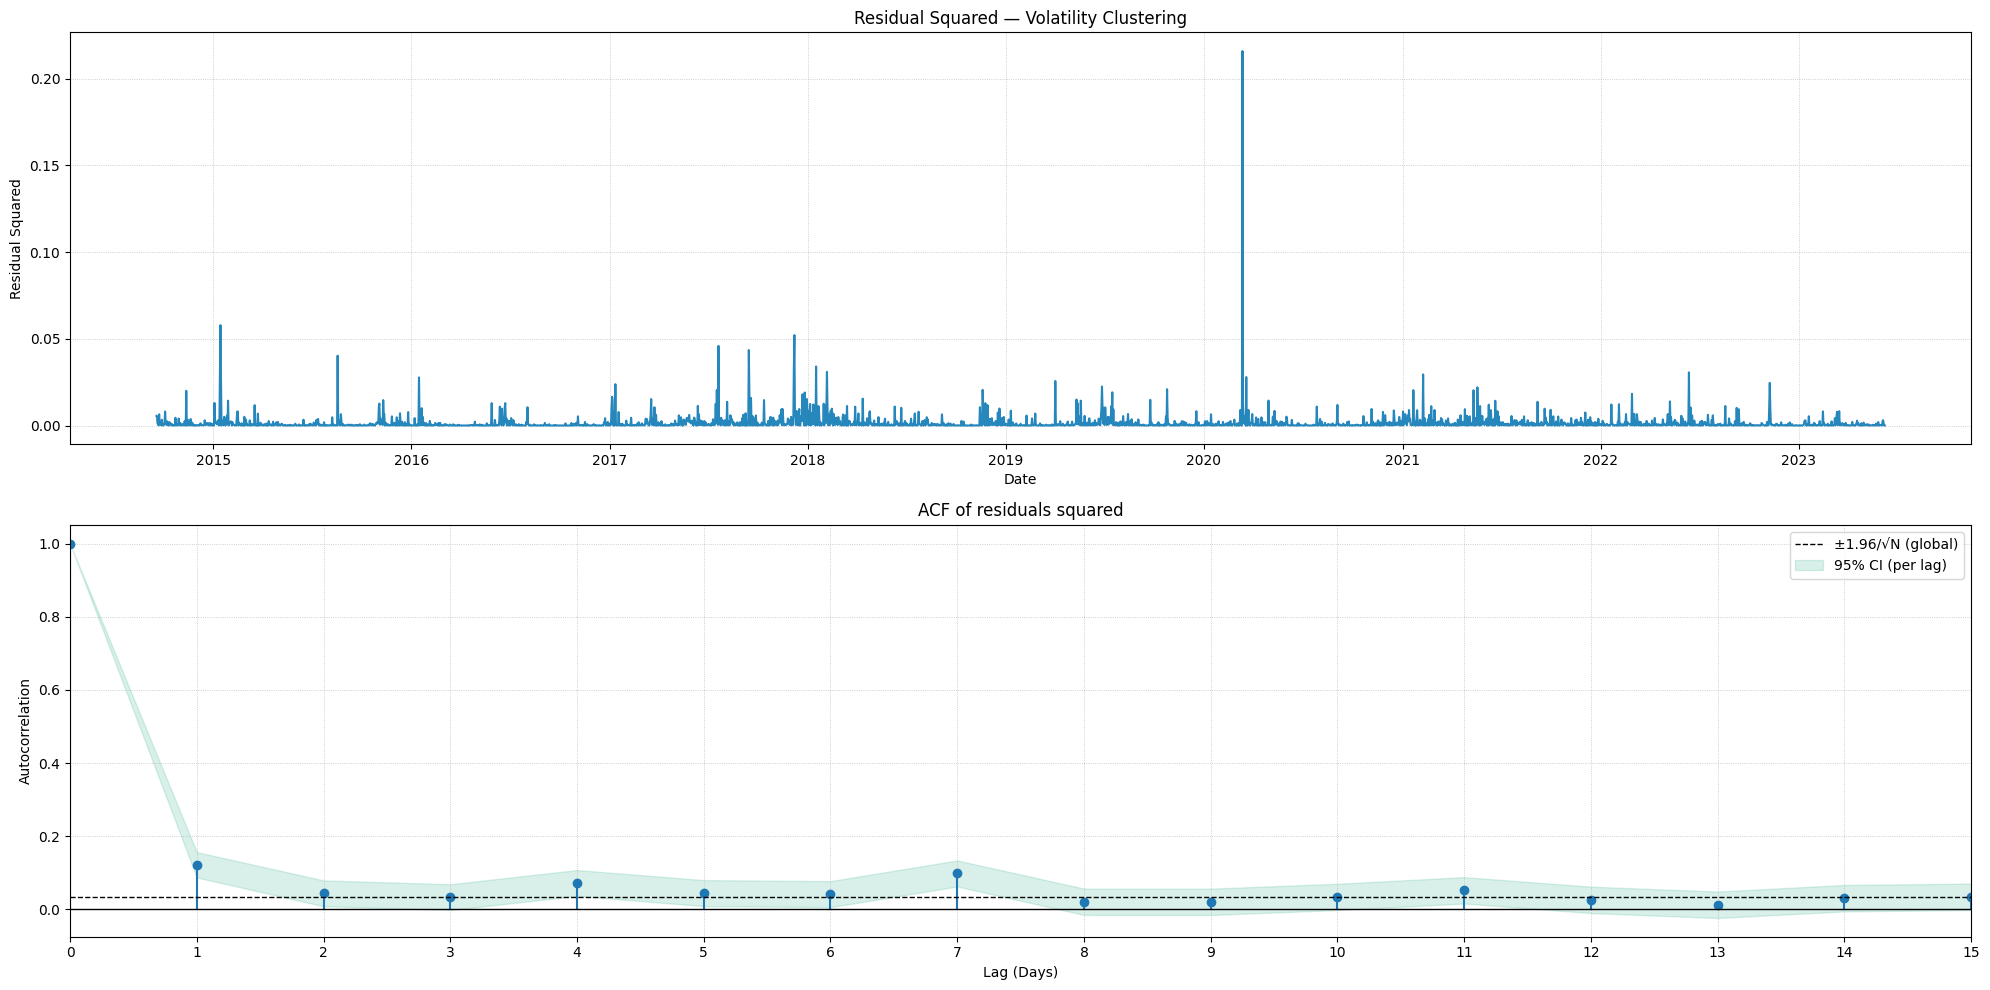


Squared Residual's Mean and Variance
╒════╤═══════════════════════════╤═══════════════════════════════╕
│    │  Squared Residual's Mean  │   Squared Residual's Variance │
╞════╪═══════════════════════════╪═══════════════════════════════╡
│ 0  │          0.0015           │                        0.0000 │
╘════╧═══════════════════════════╧═══════════════════════════════╛

Squared Residuals of ARIMA(0,1,1,'n') — Box-Cox λ=0
╒════╤══════════════════╤══════════════╤═════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╤════════╕
│    │      serie       │    model     │  trend  │  h=2   │  h=3   │  h=4   │  h=5   │  h=6   │  h=7   │  h=8   │  h=9   │  h=10  │  h=11  │  h=12  │  h=13  │  h=14  │   h=15 │
╞════╪══════════════════╪══════════════╪═════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 0  │ BoxCox_lambda{0} │ ARIMA(0,1,1) │   

In [37]:
# ARCH–LM on differenced series
lm_stat, lm_pval, f_stat, f_pval = het_arch(best_model_residuals, nlags=10)
decision = ("Reject homoskedasticity (ARCH effects present)" if (lm_pval < alpha) or (f_pval < alpha) else "Fail to reject homoskedasticity (no evidence of ARCH)")

df_lm = pd.DataFrame([{"LM statistic": round(lm_stat, 4),
                       "LM p-value"  : round(lm_pval, 4),
                       "F statistic" : round(f_stat, 4),
                       "F p-value"   : round(f_pval, 4),
                       "Decision"    : decision}])
display_table(df_lm, "ARCH LM of Residual Squared")

# Residual Squared (volatility clustering) and ACF
best_model_residuals_sq = best_model_residuals**2

fig, axes = plt.subplots(2, 1, figsize=(20, 10))
axes[0].plot(best_model_residuals_sq, color="#0072B2", alpha=0.85)
axes[0].set_title("Residual Squared — Volatility Clustering")
axes[0].set_ylabel("Residual Squared")
axes[0].set_xlabel("Date")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.8)

# Yearly ticks & formatting
year_locator = mdates.YearLocator()
year_fmt = mdates.DateFormatter("%Y")
axes[0].xaxis.set_major_locator(year_locator)
axes[0].xaxis.set_major_formatter(year_fmt)

# ACF of squared residuals
acf_vals, acf_conf = acf(best_model_residuals_sq, nlags=15, alpha=0.05, fft=False)
acf_lag_idx = np.arange(acf_vals.size)
alpha_ci = 1.96 / np.sqrt(len(best_model_residuals_sq))

# Plot ACF
axes[1].stem(acf_lag_idx, acf_vals, basefmt=" ")
axes[1].axhline(0.0, color="#000000", linewidth=1)
axes[1].axhline(alpha_ci, color="#000000", linestyle="--", linewidth=1, label="±1.96/√N (global)")
axes[1].fill_between(acf_lag_idx, acf_conf[:,0], acf_conf[:,1], color="#009E73", alpha=0.15, label="95% CI (per lag)")
axes[1].set_xlim(0, acf_lag_idx.max())
axes[1].set_xticks(np.arange(0, acf_lag_idx.max()+1, 1))
axes[1].set_xlabel("Lag (Days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("ACF of residuals squared")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

res_sq_stat_info = pd.DataFrame({"Squared Residual's Mean":     [round(np.mean(best_model_residuals_sq),4)],
                                 "Squared Residual's Variance": [round(np.var(best_model_residuals_sq),4)]})
display_table (res_sq_stat_info, "Squared Residual's Mean and Variance")

best_df_residuals_sq_bc0          = df_residuals(best_df_mdl_obj, squared=True)
best_df_residuals_sq_bc0_analysis = df_residual_independence_analysis(best_df_mdl_obj, squared=True)

display_table(best_df_residuals_sq_bc0.iloc[:1, :17], "Squared Residuals of ARIMA(0,1,1,'n') — Box-Cox λ=0")
display_table(best_df_residuals_sq_bc0_analysis.iloc[:1, :17], "Squared Residuals Independence of ARIMA(0,1,1,'n') — Box-Cox λ=0")

<u>__Conclusions:__</u>

The plot of the squared residuals shows the presence of periods of high and low volatility clustered over time, evidencing a clear pattern of volatility clustering. This visual evidence is corroborated by the results obtained for the squared residuals, which reveal statistically significant temporal dependence across the analysed lags.<br>
The results of the ARCH–LM test confirm the rejection of the homoskedasticity hypothesis, indicating the presence of ARCH effects. Additionally, the persistence of autocorrelation in the squared residuals further reinforces the existence of conditional heteroskedasticity.<br>
These findings are consistent with the previous analysis, showing that although the ARIMA model adequately captures the dynamics of the conditional mean of the series, it is not able to model the conditional variance. This fact justifies the need to resort to an alternative class of models, such as those from the GARCH family, in order to adequately capture the dynamics of volatility.

# 9. Volatility Modelling with the ARCH Family of Models

    9.1 Motivation for GARCH Modelling

The results presented in Chapter 8 indicate that the ARIMA(0,1,1) model is able to adequately capture the dynamics of the conditional mean of the time series. However, the residual analysis reveals the presence of conditional heteroskedasticity, as well as statistically significant autocorrelation in the squared residuals, indicating that the dynamics of the variance are not properly captured. Consequently, it becomes necessary to resort to models specifically designed to capture conditional variance, namely models from the GARCH family.<br>
Accordingly, the objective of this chapter is to extend the previously selected ARIMA model by incorporating a GARCH component, allowing for an explicit modelling of the volatility dynamics of the series and overcoming the limitations identified in the standalone ARIMA framework.

    9.2 Model Specification: ARIMA–GARCH Framework

As previously discussed, in addition to modelling the conditional mean of the series, it is necessary to capture the dynamics of the conditional variance. Financial time series are well known for exhibiting volatility clustering and conditional heteroskedasticity, features that cannot be adequately modelled using linear ARIMA models alone (Engle, 1982; Bollerslev, 1986). For this reason, an ARIMA–GARCH framework is adopted, allowing for the joint modelling of the mean and volatility of the time series.<br>
Having previously identified the ARIMA(0,1,1) model without deterministic terms (trend = n) as the specification that provides the best performance in modelling the conditional mean, the model equation can be expressed as:
$$
\Delta y_t = \varepsilon_t - \theta_1 \varepsilon_{t-1}
$$
where
$$
\Delta y_t = y_t - y_{t-1}
$$
In this framework, since no deterministic component is included, no constant term is considered, implicitly assuming that $\mu=0$, in line with the Box–Jenkins methodology for differenced series (Box, Jenkins, Reinsel, & Ljung, 2015). The parameter $\theta_1$ represents the coefficient associated with the moving average term, while $\varepsilon_t$ corresponds to the model innovations, that is, shocks that are not predictable based on the information available up to time $𝑡−1$.<br>
Accordingly, the innovations are assumed to be decomposed as:
$$
\varepsilon_{t} = \sigma_t z_{t},
$$
where $\sigma_t^2$ represents the conditional variance, and $z_{t}$ is an independent and identically distributed (i.i.d.) process with zero mean and unit variance. In this way, all temporal dependence in volatility is captured by the dynamics of $\sigma_t^2$, while the process $z_t$ represents a serially uncorrelated noise component (Engle, 1982; Bollerslev, 1986).<br>
The conditional variance is then modelled through a GARCH(𝑝,𝑞), process, given by:
$$
\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2
           + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2
$$
where $𝜔>0$, $𝛼𝑖≥0$ e $𝛽𝑗≥0$, ensuring that the conditional variance remains strictly positive. The coefficients $\alpha_i$ capture the impact of recent shocks on volatility, while the coefficients $\beta_j$ reflect the persistence of volatility over time, (Cont, 2001).<br>
In this chapter, different specifications from the GARCH family will be evaluated, including the GARCH, EGARCH (Nelson, 1991), and GJR-GARCH (Glosten, Jagannathan, & Runkle, 1993) models, with the objective of identifying the formulation that best describes the volatility dynamics of the series. After selecting the most appropriate volatility model, it will be integrated with the previously estimated ARIMA model, forming the final ARIMA–GARCH framework.

    9.3 Estimation of GARCH-type Models

In this chapter, three classes of volatility models are specified in order to capture the conditional variance dynamics of the series, namely GARCH, EGARCH and GJR-GARCH models. The GARCH(𝑝,𝑞), specification captures volatility clustering through symmetric responses to past shocks, as originally proposed by Bollerslev (1986). Extensions such as the EGARCH model allow for asymmetric volatility effects and relax the non negativity constraints on the parameters (Nelson, 1991).<br>
All models are estimated via Maximum Likelihood Estimation (MLE), assuming alternative conditional distributions for the standardized innovations $z_t$, namely the Gaussian distribution, and the Student’s t distribution.<br>
The selection of the lag orders 𝑝 and 𝑞 is guided by a combination of information criteria (AIC, BIC and HQIC) and the principle of model parsimony. The estimated models are first evaluated in terms of their in-sample fit and subsequently subjected to a comprehensive diagnostic analysis, including tests for residual autocorrelation, remaining ARCH effects, and the adequacy of the assumed conditional distribution.

In [38]:
def optimal_arch_parameters(residuals: pd.Series, max_p_arch: int = 3, max_q_arch: int = 3, hide_progress: bool = False):
    """
    Fit a grid of volatility models (GARCH, EGARCH, GJR-GARCH) to a residual series.
    The function always tests the three volatility specifications:
      - GARCH(p,q)
      - EGARCH(p,q)
      - GJR-GARCH(p,q)
    Each specification is estimated via Maximum Likelihood under the selected conditional
    distribution(s) for standardized innovations.

    Parameters
    ----------
    residuals (pd.Series): Residuals from the mean model.
    max_p_arch, max_q_arch (int): Inclusive search bounds for p, q.

    Returns
    -------
    df_arch_models_res (pd.DataFrame): Dataframe with one row per fitted specification, including information criteria, log-likelihood, 
                                       convergence flag.
    """

    arch_models = [("GARCH",     {"vol": "GARCH",  "o": 0}),
                   ("EGARCH",    {"vol": "EGARCH", "o": 0}),
                   ("GJR-GARCH", {"vol": "GARCH",  "o": 1})]

    combinations = []
    dists = ("normal", "t")

    grid_pq = list(product(range(max_p_arch + 1), range(max_q_arch + 1)))

    for (p_arch, q_arch) in grid_pq:
        for (vol_name, vol_kwargs) in arch_models:
            for dist in dists:

                # Invalid specification: no ARCH or leverage terms
                if p_arch == 0 and vol_kwargs["o"] == 0:
                    continue

                combinations.append((vol_name, vol_kwargs, p_arch, q_arch, dist))

    total_combinations = len(combinations)

    arch_models_res = []

    for (vol_name, vol_kwargs, p_arch, q_arch, dist) in tqdm(combinations, total=total_combinations, ncols=100, colour="green",
                                                             desc="Grid Search (Volatility)", disable=hide_progress):
        try:
            arch_models = arch_model(residuals, mean="Zero", p=int(p_arch), q=int(q_arch), o=int(vol_kwargs["o"]),
                                     vol=vol_kwargs["vol"], dist=dist, rescale=True)
            
            arch_res = arch_models.fit(disp="off")

            conv_flag = int(getattr(arch_res, "convergence_flag", 0))
            converged = (conv_flag == 0)

            T = arch_res.nobs
            k = arch_res.num_params
            hqic = -2 * arch_res.loglikelihood + 2 * k * np.log(np.log(T))

            arch_models_res.append({"vol_model": vol_name,
                                    "p": int(p_arch),
                                    "q": int(q_arch),
                                    "o": int(vol_kwargs["o"]),
                                    "dist": dist,
                                    "loglik": float(arch_res.loglikelihood),
                                    "AIC": float(arch_res.aic),
                                    "BIC": float(arch_res.bic),
                                    "HQIC": float(hqic),
                                    "converged": bool(converged)})

        except Exception as e:
            print(f"(p{p},q{q}) -> {type(e).__name__}: {e}")
            continue

    df_arch_models_res = pd.DataFrame(arch_models_res)

    return df_arch_models_res

In [39]:
# Create the directory for ARCH models objects
ARCH_MODELS_DIR = "arch_models_objects"
os.makedirs(ARCH_MODELS_DIR, exist_ok=True)

df_vol_grid = optimal_arch_parameters(residuals=best_model_residuals, max_p_arch=4, max_q_arch=4, hide_progress=False)

Grid Search (Volatility):  73%|██████████████████████████▎         | 95/130 [00:10<00:07,  4.50it/s]d:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\MThesis_env\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
Grid Search (Volatility): 100%|███████████████████████████████████| 130/130 [00:15<00:00,  8.22it/s]


In [40]:
csv_path = os.path.join(ARCH_MODELS_DIR, "volatility_grid_results.csv")
pkl_path = os.path.join(ARCH_MODELS_DIR, "volatility_grid_results.pkl")

df_vol_grid.to_csv(csv_path, index=False)

with open(pkl_path, "wb") as f:
    pickle.dump(df_vol_grid, f, protocol=pickle.HIGHEST_PROTOCOL)

display_table(df_vol_grid.sort_values("HQIC").head(5), "Volatility Grid Search — Top 15 Models by HQIC")


Volatility Grid Search — Top 15 Models by HQIC
╒════╤═════════════╤═════╤═════╤═════╤════════╤═══════════╤═══════════╤═══════════╤═══════════╤═════════════╕
│    │  vol_model  │  p  │  q  │  o  │  dist  │  loglik   │    AIC    │    BIC    │   HQIC    │ converged   │
╞════╪═════════════╪═════╪═════╪═════╪════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════════════╡
│ 49 │   EGARCH    │  2  │  1  │  0  │   t    │ -727.0456 │ 1464.0911 │ 1494.4253 │ 1474.9687 │ True        │
├────┼─────────────┼─────┼─────┼─────┼────────┼───────────┼───────────┼───────────┼───────────┼─────────────┤
│ 25 │   EGARCH    │  1  │  2  │  0  │   t    │ -727.6287 │ 1465.2575 │ 1495.5917 │ 1476.1351 │ True        │
├────┼─────────────┼─────┼─────┼─────┼────────┼───────────┼───────────┼───────────┼───────────┼─────────────┤
│ 19 │   EGARCH    │  1  │  1  │  0  │   t    │ -729.8472 │ 1467.6943 │ 1491.9617 │ 1476.3964 │ True        │
├────┼─────────────┼─────┼─────┼─────┼────────┼───────────┼───────────┼─

    9.4 Volatility Diagnostics and Residual Analysis

    9.5 Out-of-Sample Volatility Forecasting Performance

    9.6 Discussion and Comparison with ARIMA-only Models